In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from prophet import Prophet

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
trend_df = pd.read_csv("merged_skills_dataset.csv")

trend_df.head()

,Time,C++,Cloud_Computing,Communication,Computer_Vision,Data_Visualization,Deep_Learning,Generative_AI,JAVA,Machine_Learning,...,NLP,Problem_Solving,Project_Management,Python,Pytorch,R,Scikit-Learn,SQL,Statistics,TensorFlow
0,2023-03-01,95,23,47,18,52,28,13,82,30,...,79,70,55,100,94,83,99,100,39,100
1,2023-04-01,89,21,45,18,53,25,16,77,30,...,72,67,72,94,95,88,100,92,39,89
2,2023-05-01,71,21,43,16,46,22,27,70,27,...,67,57,49,86,80,78,73,87,35,70
3,2023-06-01,65,18,36,17,41,21,38,69,26,...,68,40,49,84,76,74,63,92,23,72
4,2023-07-01,65,19,34,16,42,21,30,69,25,...,65,36,49,81,76,72,62,86,24,70


In [5]:
trend_df.shape

(36, 21)

In [7]:
trend_df.columns.tolist()

['Time',
 'C++',
 'Cloud_Computing',
 'Communication',
 'Computer_Vision',
 'Data_Visualization',
 'Deep_Learning',
 'Generative_AI',
 'JAVA',
 'Machine_Learning',
 'MLOps',
 'NLP',
 'Problem_Solving',
 'Project_Management',
 'Python',
 'Pytorch',
 'R',
 'Scikit-Learn',
 'SQL',
 'Statistics',
 'TensorFlow']

In [9]:
trend_df["Time"] = pd.to_datetime(trend_df["Time"], errors="coerce")

trend_df = trend_df.dropna(subset=["Time"])

trend_df = trend_df.sort_values("Time")

trend_df.head()

,Time,C++,Cloud_Computing,Communication,Computer_Vision,Data_Visualization,Deep_Learning,Generative_AI,JAVA,Machine_Learning,...,NLP,Problem_Solving,Project_Management,Python,Pytorch,R,Scikit-Learn,SQL,Statistics,TensorFlow
0,2023-03-01,95,23,47,18,52,28,13,82,30,...,79,70,55,100,94,83,99,100,39,100
1,2023-04-01,89,21,45,18,53,25,16,77,30,...,72,67,72,94,95,88,100,92,39,89
2,2023-05-01,71,21,43,16,46,22,27,70,27,...,67,57,49,86,80,78,73,87,35,70
3,2023-06-01,65,18,36,17,41,21,38,69,26,...,68,40,49,84,76,74,63,92,23,72
4,2023-07-01,65,19,34,16,42,21,30,69,25,...,65,36,49,81,76,72,62,86,24,70


In [11]:
trend_df = trend_df.set_index("Time")

trend_df.head()

,C++,Cloud_Computing,Communication,Computer_Vision,Data_Visualization,Deep_Learning,Generative_AI,JAVA,Machine_Learning,MLOps,NLP,Problem_Solving,Project_Management,Python,Pytorch,R,Scikit-Learn,SQL,Statistics,TensorFlow
Time,,,,,,,,,,,,,,,,,,,,
2023-03-01,95,23,47,18,52,28,13,82,30,36,79,70,55,100,94,83,99,100,39,100
2023-04-01,89,21,45,18,53,25,16,77,30,33,72,67,72,94,95,88,100,92,39,89
2023-05-01,71,21,43,16,46,22,27,70,27,35,67,57,49,86,80,78,73,87,35,70
2023-06-01,65,18,36,17,41,21,38,69,26,35,68,40,49,84,76,74,63,92,23,72
2023-07-01,65,19,34,16,42,21,30,69,25,33,65,36,49,81,76,72,62,86,24,70


In [13]:
trend_df.index

DatetimeIndex(['2023-03-01', '2023-04-01', '2023-05-01', '2023-06-01',
               '2023-07-01', '2023-08-01', '2023-09-01', '2023-10-01',
               '2023-11-01', '2023-12-01', '2024-01-01', '2024-02-01',
               '2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01',
               '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01',
               '2025-03-01', '2025-04-01', '2025-05-01', '2025-06-01',
               '2025-07-01', '2025-08-01', '2025-09-01', '2025-10-01',
               '2025-11-01', '2025-12-01', '2026-01-01', '2026-02-01'],
              dtype='datetime64[ns]', name='Time', freq=None)

In [15]:
trend_df.columns.tolist()

['C++',
 'Cloud_Computing',
 'Communication',
 'Computer_Vision',
 'Data_Visualization',
 'Deep_Learning',
 'Generative_AI',
 'JAVA',
 'Machine_Learning',
 'MLOps',
 'NLP',
 'Problem_Solving',
 'Project_Management',
 'Python',
 'Pytorch',
 'R',
 'Scikit-Learn',
 'SQL',
 'Statistics',
 'TensorFlow']

In [17]:
for col in trend_df.columns:
    trend_df[col] = pd.to_numeric(trend_df[col], errors="coerce")

In [19]:
trend_df.isna().sum()

C++                   0
Cloud_Computing       0
Communication         0
Computer_Vision       0
Data_Visualization    0
Deep_Learning         0
Generative_AI         0
JAVA                  0
Machine_Learning      0
MLOps                 0
NLP                   0
Problem_Solving       0
Project_Management    0
Python                0
Pytorch               0
R                     0
Scikit-Learn          0
SQL                   0
Statistics            0
TensorFlow            0
dtype: int64

In [21]:
skills_to_forecast = trend_df.columns.tolist()

skills_to_forecast

['C++',
 'Cloud_Computing',
 'Communication',
 'Computer_Vision',
 'Data_Visualization',
 'Deep_Learning',
 'Generative_AI',
 'JAVA',
 'Machine_Learning',
 'MLOps',
 'NLP',
 'Problem_Solving',
 'Project_Management',
 'Python',
 'Pytorch',
 'R',
 'Scikit-Learn',
 'SQL',
 'Statistics',
 'TensorFlow']

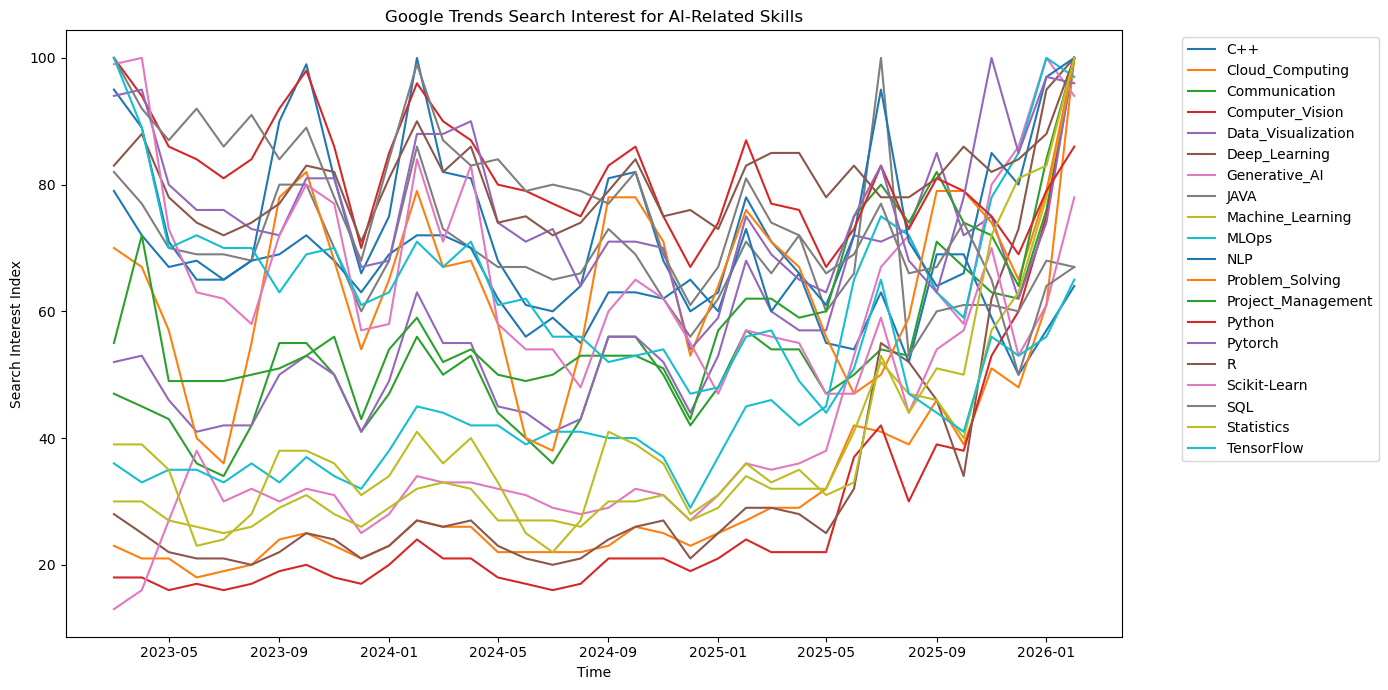

In [23]:
plt.figure(figsize=(14, 7))

for col in trend_df.columns:
    plt.plot(trend_df.index, trend_df[col], label=col)

plt.title("Google Trends Search Interest for AI-Related Skills")
plt.xlabel("Time")
plt.ylabel("Search Interest Index")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

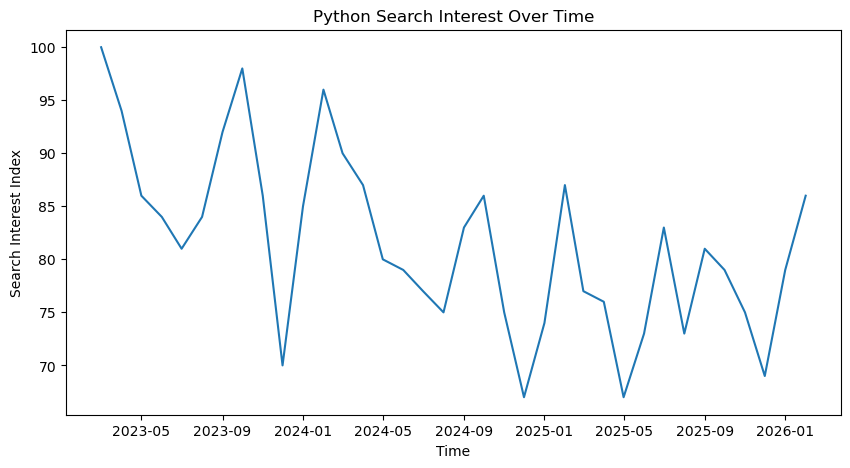

In [25]:
# Single Skill
skill = "Python"

plt.figure(figsize=(10, 5))
plt.plot(trend_df.index, trend_df[skill])
plt.title(f"{skill} Search Interest Over Time")
plt.xlabel("Time")
plt.ylabel("Search Interest Index")
plt.show()

In [27]:
def time_series_split(series, test_ratio=0.2):
    n = len(series)
    train_size = int(n * (1 - test_ratio))
    
    train = series.iloc[:train_size]
    test = series.iloc[train_size:]
    
    return train, test

In [29]:
train, test = time_series_split(trend_df["Python"], test_ratio=0.2)

train.shape, test.shape

((28,), (8,))

In [31]:
def stationarity_tests(series):
    series = series.dropna()
    
    print("ADF Test")
    adf_result = adfuller(series)
    print("ADF Statistic:", adf_result[0])
    print("ADF p-value:", adf_result[1])
    
    if adf_result[1] < 0.05:
        print("ADF result: stationary")
    else:
        print("ADF result: non-stationary")
    
    print("\nKPSS Test")
    kpss_result = kpss(series, regression="c", nlags="auto")
    print("KPSS Statistic:", kpss_result[0])
    print("KPSS p-value:", kpss_result[1])
    
    if kpss_result[1] < 0.05:
        print("KPSS result: non-stationary")
    else:
        print("KPSS result: stationary")

In [33]:
stationarity_tests(trend_df["Python"])
stationarity_tests(trend_df["Machine_Learning"])
stationarity_tests(trend_df["Generative_AI"])

ADF Test
ADF Statistic: -1.4976294419413758
ADF p-value: 0.5346836924409233
ADF result: non-stationary

KPSS Test
KPSS Statistic: 0.805462271973466
KPSS p-value: 0.01
KPSS result: non-stationary
ADF Test
ADF Statistic: 4.783938191000297
ADF p-value: 1.0
ADF result: non-stationary

KPSS Test
KPSS Statistic: 0.679049366939283
KPSS p-value: 0.015450057550974275
KPSS result: non-stationary
ADF Test
ADF Statistic: 2.7127283419799957
ADF p-value: 0.9990875847326238
ADF result: non-stationary

KPSS Test
KPSS Statistic: 0.7431088683154343
KPSS p-value: 0.01
KPSS result: non-stationary


C:\Users\Liliu\AppData\Local\Temp\ipykernel_40068\2954016662.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression="c", nlags="auto")
C:\Users\Liliu\AppData\Local\Temp\ipykernel_40068\2954016662.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression="c", nlags="auto")


In [35]:
# Prophet on single skill
skill = "Python"

series = trend_df[skill].dropna()

train, test = time_series_split(series, test_ratio=0.2)

prophet_train = train.reset_index()
prophet_train.columns = ["ds", "y"]

prophet_test = test.reset_index()
prophet_test.columns = ["ds", "y"]

prophet_train.head()

,ds,y
0,2023-03-01,100
1,2023-04-01,94
2,2023-05-01,86
3,2023-06-01,84
4,2023-07-01,81


In [37]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(prophet_train)

16:53:11 - cmdstanpy - INFO - Chain [1] start processing
16:53:11 - cmdstanpy - INFO - Chain [1] done processing


In [39]:
future_test = model.make_future_dataframe(
    periods=len(prophet_test),
    freq="M"
)

forecast_test = model.predict(future_test)

forecast_test[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
31,2025-09-30,81.025959,79.619594,82.438463
32,2025-10-31,67.209150,65.789164,68.553732
33,2025-11-30,45.282719,43.960233,46.642116
34,2025-12-31,65.057309,63.554256,66.440150
35,2026-01-31,74.108525,72.643920,75.664182


In [41]:
prophet_pred = forecast_test["yhat"].iloc[-len(prophet_test):].values

actual = prophet_test["y"].values

prophet_mae = mean_absolute_error(actual, prophet_pred)

prophet_rmse = np.sqrt(mean_squared_error(actual, prophet_pred))

print("Prophet MAE:", prophet_mae)
print("Prophet RMSE:", prophet_rmse)

Prophet MAE: 11.716463798521609
Prophet RMSE: 13.737540118877156


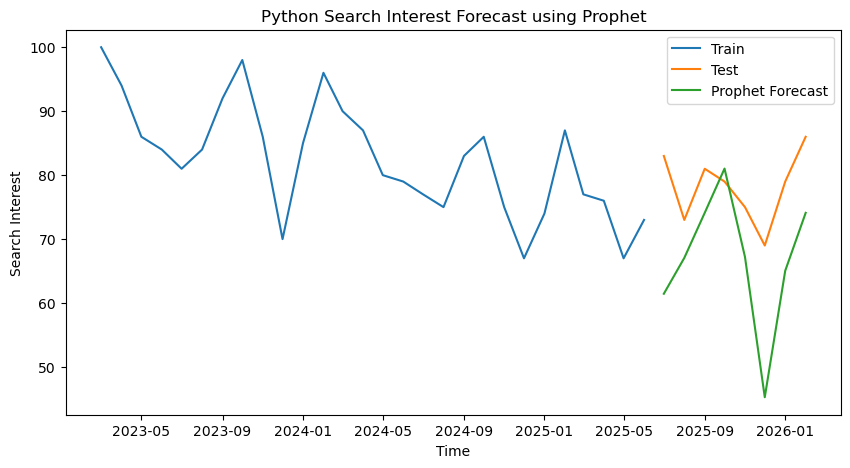

In [43]:
plt.figure(figsize=(10, 5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, prophet_pred, label="Prophet Forecast")

plt.title(f"{skill} Search Interest Forecast using Prophet")
plt.xlabel("Time")
plt.ylabel("Search Interest")
plt.legend()
plt.show()

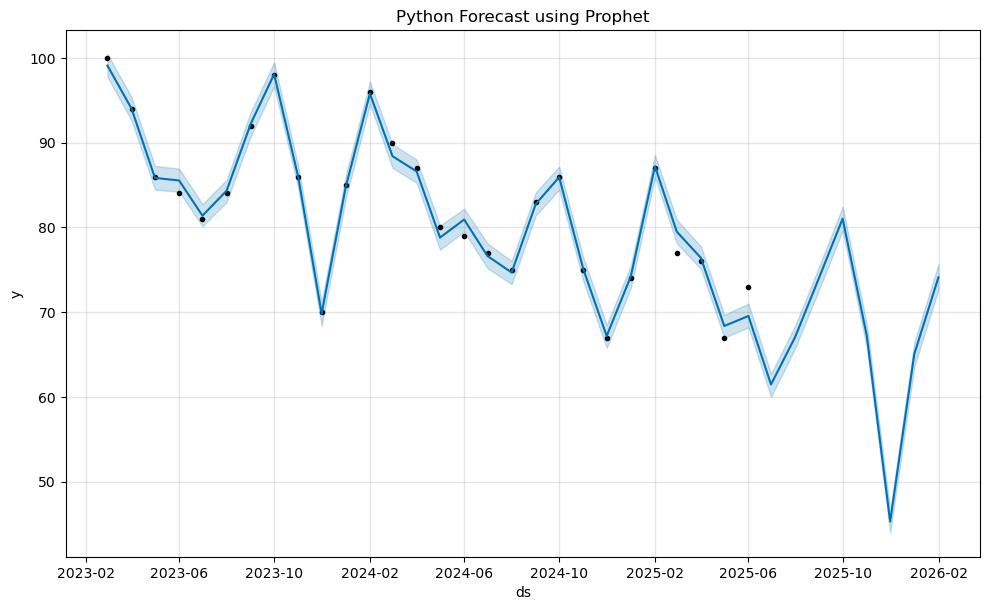

In [45]:
model.plot(forecast_test)
plt.title(f"{skill} Forecast using Prophet")
plt.show()

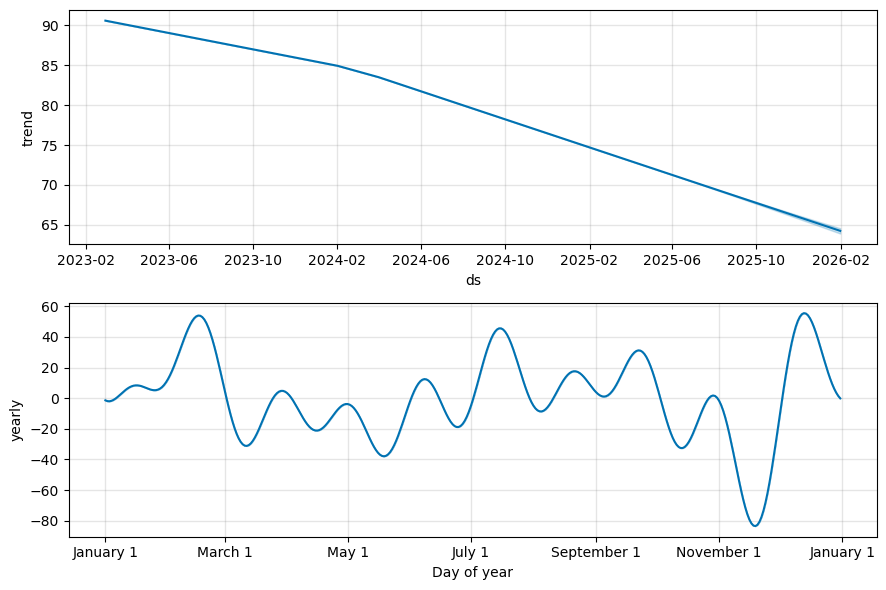

In [47]:
model.plot_components(forecast_test)
plt.show()

In [49]:
# ARIMA on single skill
arima_model = ARIMA(train, order=(1, 1, 1))

arima_fit = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 Python   No. Observations:                   28
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -92.634
Date:                Tue, 28 Apr 2026   AIC                            191.269
Time:                        16:54:58   BIC                            195.156
Sample:                    03-01-2023   HQIC                           192.425
                         - 06-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4200      0.347      1.209      0.227      -0.261       1.101
ma.L1         -0.8232      0.232     -3.553      0.000      -1.277      -0.369
sigma2        54.9419     18.863      2.913      0.0

C:\Users\Liliu\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Liliu\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Liliu\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [51]:
arima_pred = arima_fit.forecast(steps=len(test))

arima_pred.head()

2025-07-01    74.445915
2025-08-01    75.053130
2025-09-01    75.308132
2025-10-01    75.415221
2025-11-01    75.460193
Freq: MS, Name: predicted_mean, dtype: float64

In [53]:
arima_mae = mean_absolute_error(test, arima_pred)

arima_rmse = np.sqrt(mean_squared_error(test, arima_pred))

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)

ARIMA MAE: 5.105722953950298
ARIMA RMSE: 5.996040354514847


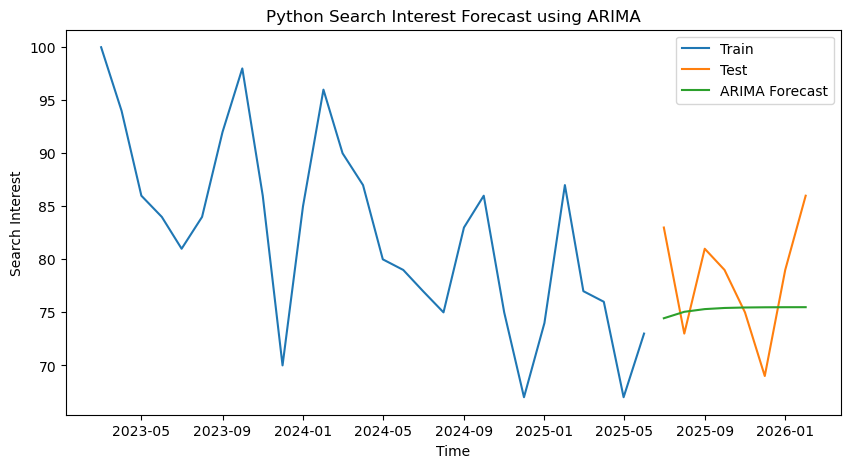

In [55]:
plt.figure(figsize=(10, 5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, arima_pred, label="ARIMA Forecast")

plt.title(f"{skill} Search Interest Forecast using ARIMA")
plt.xlabel("Time")
plt.ylabel("Search Interest")
plt.legend()
plt.show()

In [57]:
# Prophet vs ARIMA
model_comparison = pd.DataFrame({
    "Model": ["Prophet", "ARIMA"],
    "MAE": [prophet_mae, arima_mae],
    "RMSE": [prophet_rmse, arima_rmse]
})

model_comparison

,Model,MAE,RMSE
0,Prophet,11.716464,13.73754
1,ARIMA,5.105723,5.99604


In [59]:
model_comparison.to_csv(
    f"{skill}_model_comparison.csv",
    index=False
)

17:11:31 - cmdstanpy - INFO - Chain [1] start processing



Forecasting C++


17:11:31 - cmdstanpy - INFO - Chain [1] done processing
17:11:31 - cmdstanpy - INFO - Chain [1] start processing


Prophet MAE: 9.4282415614052
Prophet RMSE: 10.949831877250682


17:11:31 - cmdstanpy - INFO - Chain [1] done processing


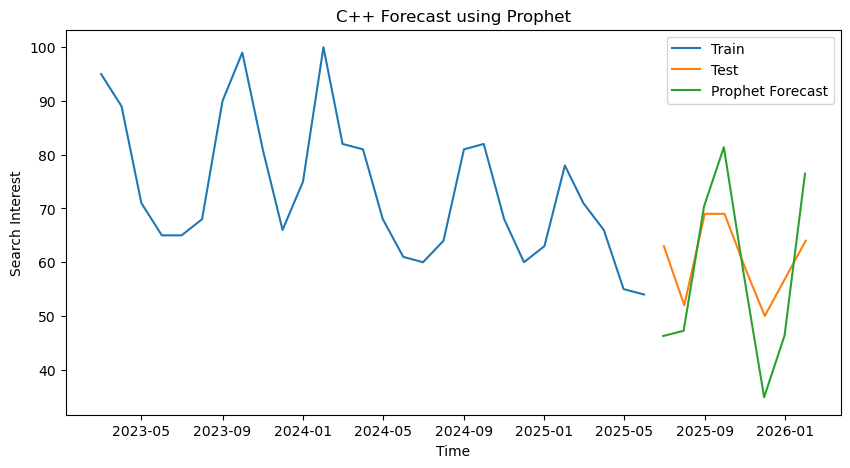

17:11:32 - cmdstanpy - INFO - Chain [1] start processing
17:11:32 - cmdstanpy - INFO - Chain [1] done processing



Forecasting Cloud_Computing


17:11:32 - cmdstanpy - INFO - Chain [1] start processing


Prophet MAE: 22.663311295439126
Prophet RMSE: 28.440845473802906


17:11:32 - cmdstanpy - INFO - Chain [1] done processing


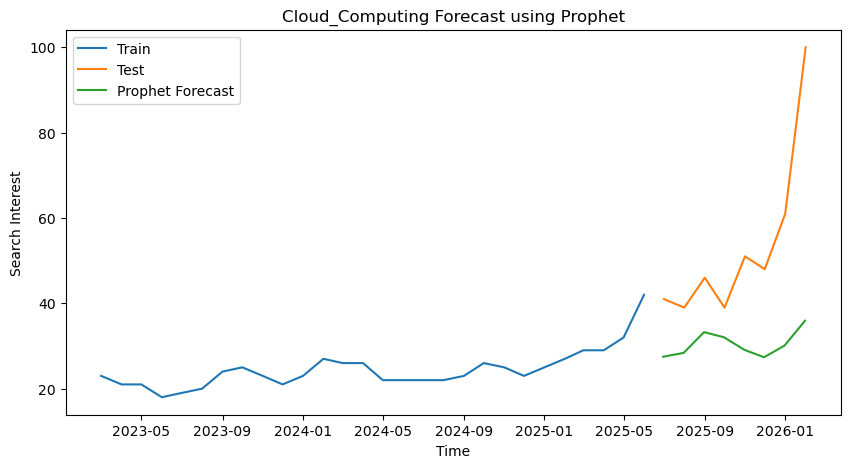

17:11:32 - cmdstanpy - INFO - Chain [1] start processing



Forecasting Communication


17:11:33 - cmdstanpy - INFO - Chain [1] done processing
17:11:33 - cmdstanpy - INFO - Chain [1] start processing


Prophet MAE: 10.520499922971727
Prophet RMSE: 13.837820753035258


17:11:33 - cmdstanpy - INFO - Chain [1] done processing


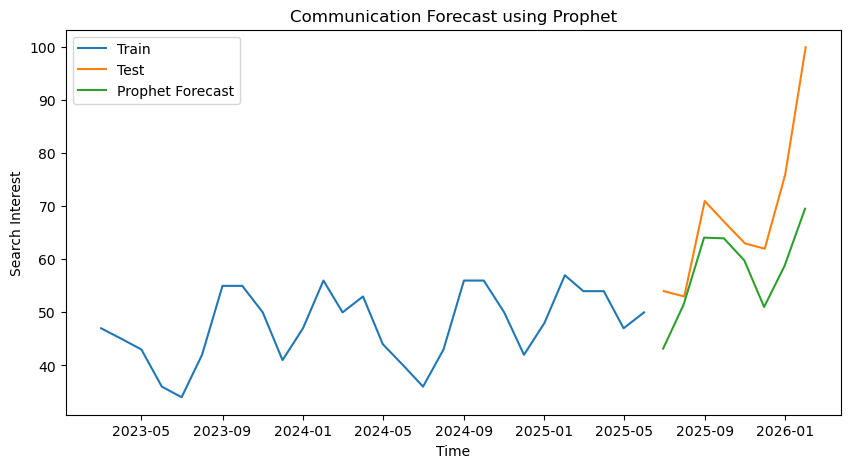

17:11:33 - cmdstanpy - INFO - Chain [1] start processing
17:11:34 - cmdstanpy - INFO - Chain [1] done processing



Forecasting Computer_Vision


17:11:34 - cmdstanpy - INFO - Chain [1] start processing


Prophet MAE: 30.00604959355143
Prophet RMSE: 35.9794129708745


17:11:34 - cmdstanpy - INFO - Chain [1] done processing


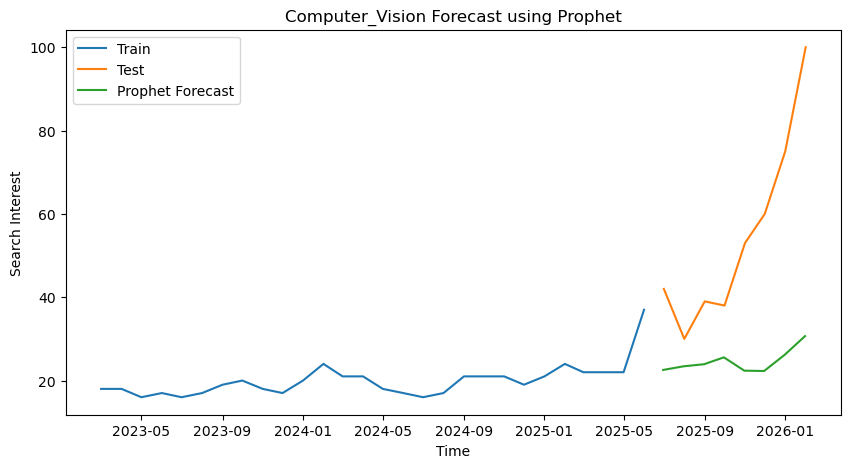

17:11:34 - cmdstanpy - INFO - Chain [1] start processing



Forecasting Data_Visualization


17:11:34 - cmdstanpy - INFO - Chain [1] done processing
17:11:34 - cmdstanpy - INFO - Chain [1] start processing


Prophet MAE: 16.049429677837495
Prophet RMSE: 17.35321962276473


17:11:35 - cmdstanpy - INFO - Chain [1] done processing


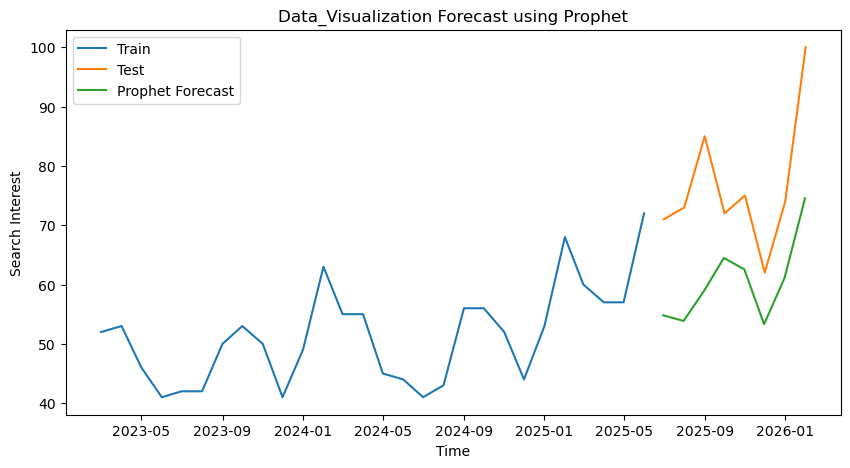

17:11:35 - cmdstanpy - INFO - Chain [1] start processing
17:11:35 - cmdstanpy - INFO - Chain [1] done processing



Forecasting Deep_Learning


17:11:35 - cmdstanpy - INFO - Chain [1] start processing


Prophet MAE: 37.151477671221315
Prophet RMSE: 42.711854458457296


17:11:36 - cmdstanpy - INFO - Chain [1] done processing


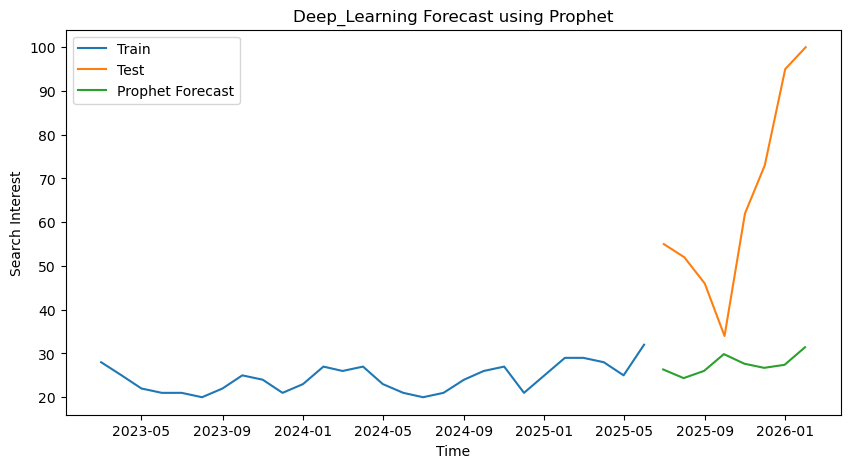

17:11:36 - cmdstanpy - INFO - Chain [1] start processing



Forecasting Generative_AI


17:11:36 - cmdstanpy - INFO - Chain [1] done processing
17:11:36 - cmdstanpy - INFO - Chain [1] start processing


Prophet MAE: 37.71602370377455
Prophet RMSE: 39.375728979348814


17:11:36 - cmdstanpy - INFO - Chain [1] done processing


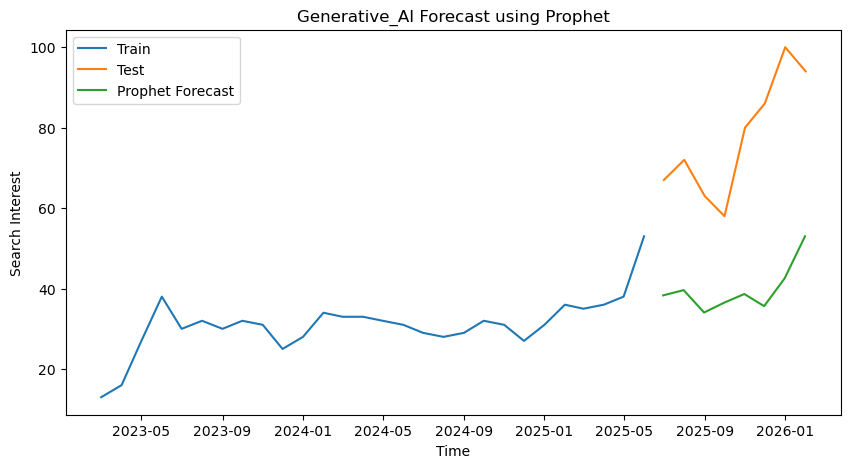

17:11:37 - cmdstanpy - INFO - Chain [1] start processing
17:11:37 - cmdstanpy - INFO - Chain [1] done processing



Forecasting JAVA


17:11:37 - cmdstanpy - INFO - Chain [1] start processing


Prophet MAE: 13.76834795526391
Prophet RMSE: 17.341151066902384


17:11:37 - cmdstanpy - INFO - Chain [1] done processing


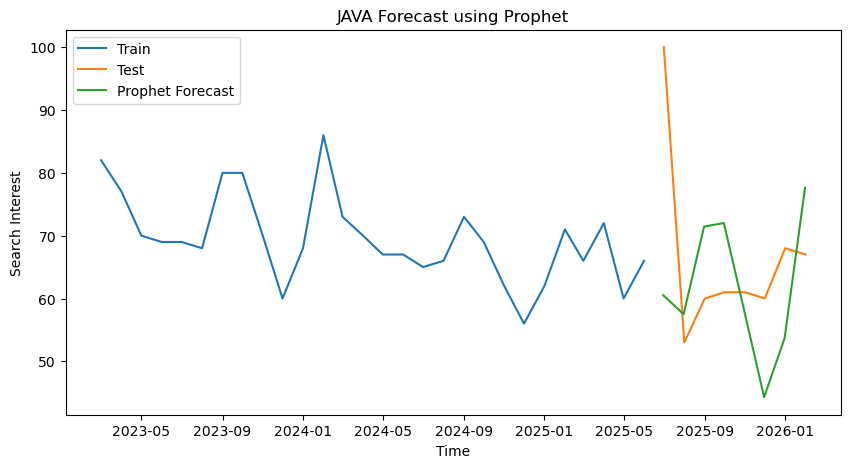

17:11:37 - cmdstanpy - INFO - Chain [1] start processing
17:11:38 - cmdstanpy - INFO - Chain [1] done processing



Forecasting Machine_Learning


17:11:38 - cmdstanpy - INFO - Chain [1] start processing


Prophet MAE: 28.034802980024175
Prophet RMSE: 33.219011341961135


17:11:38 - cmdstanpy - INFO - Chain [1] done processing


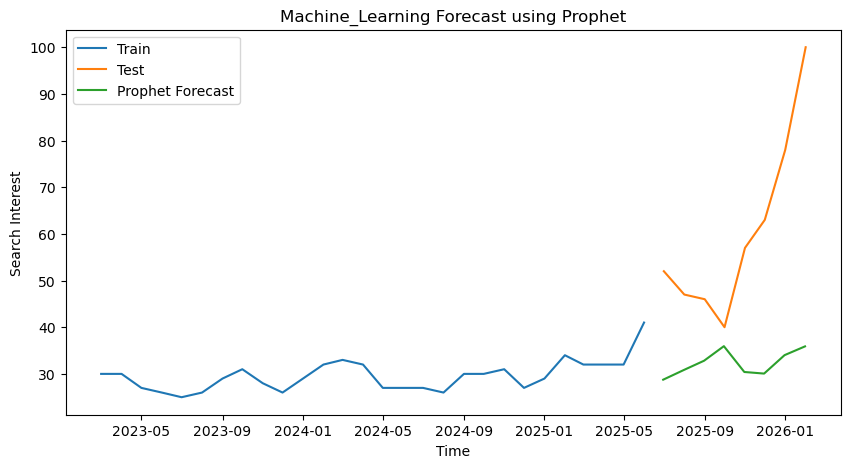

17:11:39 - cmdstanpy - INFO - Chain [1] start processing



Forecasting MLOps


17:11:39 - cmdstanpy - INFO - Chain [1] done processing
17:11:39 - cmdstanpy - INFO - Chain [1] start processing


Prophet MAE: 32.116278707937
Prophet RMSE: 34.4540692703608


17:11:39 - cmdstanpy - INFO - Chain [1] done processing


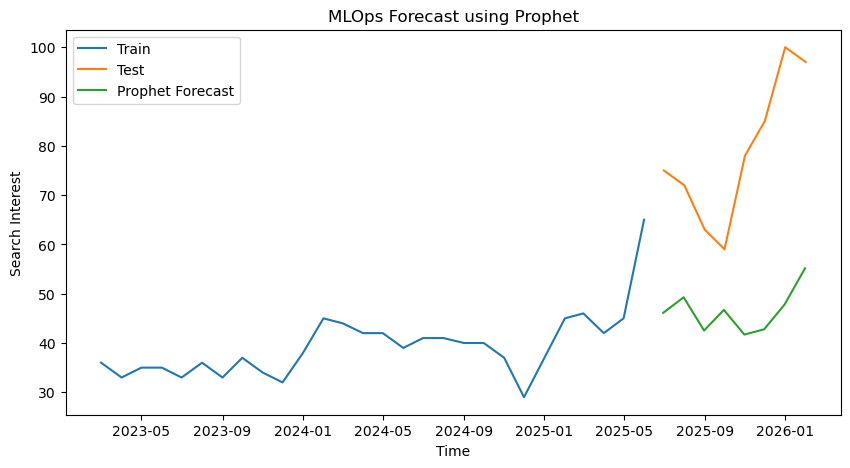

17:11:39 - cmdstanpy - INFO - Chain [1] start processing



Forecasting NLP


17:11:39 - cmdstanpy - INFO - Chain [1] done processing
17:11:40 - cmdstanpy - INFO - Chain [1] start processing


Prophet MAE: 19.84617592977486
Prophet RMSE: 23.87163821035102


17:11:40 - cmdstanpy - INFO - Chain [1] done processing


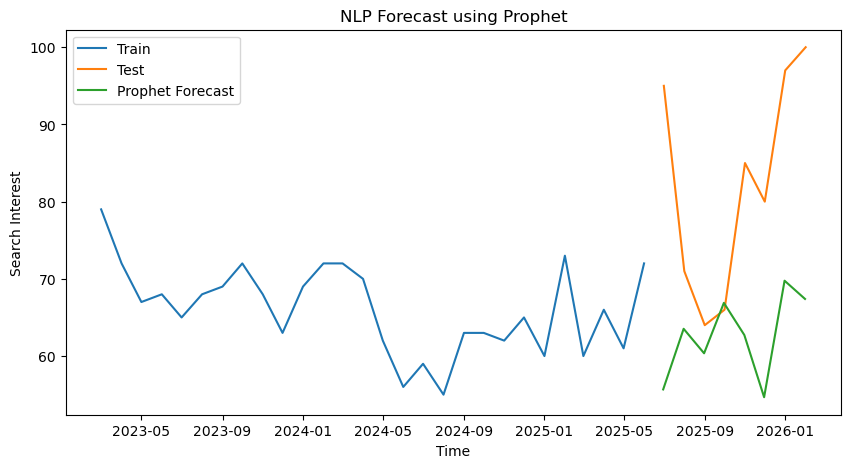

17:11:40 - cmdstanpy - INFO - Chain [1] start processing



Forecasting Problem_Solving


17:11:40 - cmdstanpy - INFO - Chain [1] done processing
17:11:41 - cmdstanpy - INFO - Chain [1] start processing


Prophet MAE: 8.438391614704464
Prophet RMSE: 9.984349969349736


17:11:41 - cmdstanpy - INFO - Chain [1] done processing


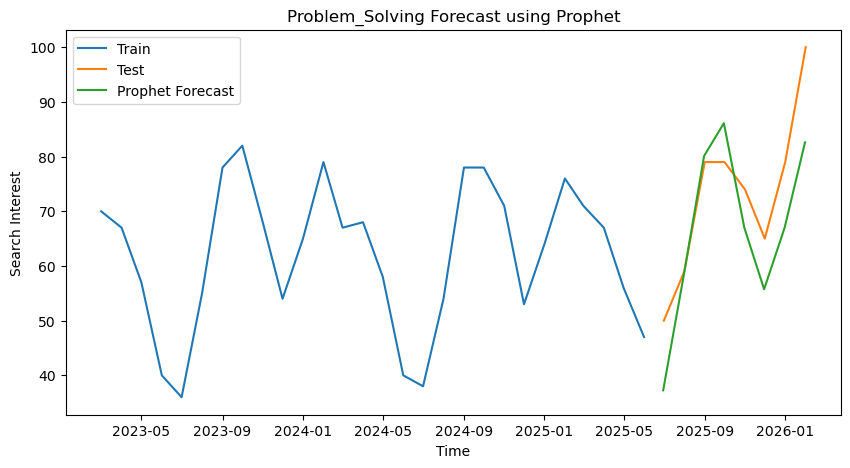

17:11:41 - cmdstanpy - INFO - Chain [1] start processing
17:11:41 - cmdstanpy - INFO - Chain [1] done processing



Forecasting Project_Management


17:11:41 - cmdstanpy - INFO - Chain [1] start processing


Prophet MAE: 22.677895780505068
Prophet RMSE: 24.768280949422007


17:11:42 - cmdstanpy - INFO - Chain [1] done processing


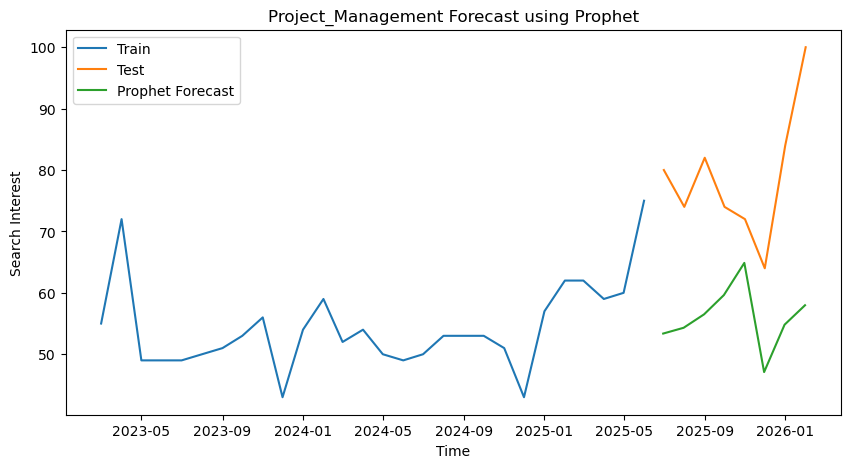

17:11:42 - cmdstanpy - INFO - Chain [1] start processing



Forecasting Python


17:11:42 - cmdstanpy - INFO - Chain [1] done processing
17:11:42 - cmdstanpy - INFO - Chain [1] start processing


Prophet MAE: 11.716463798521609
Prophet RMSE: 13.737540118877156


17:11:43 - cmdstanpy - INFO - Chain [1] done processing


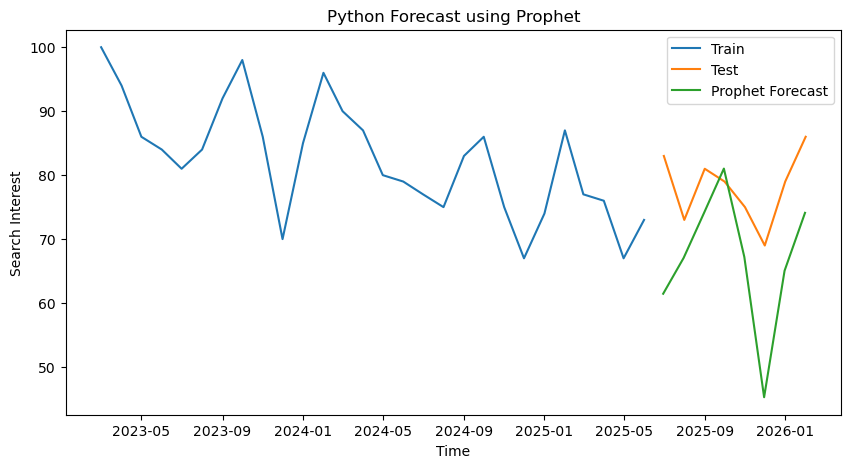

17:11:43 - cmdstanpy - INFO - Chain [1] start processing



Forecasting Pytorch


17:11:43 - cmdstanpy - INFO - Chain [1] done processing
17:11:43 - cmdstanpy - INFO - Chain [1] start processing


Prophet MAE: 25.59215457602783
Prophet RMSE: 29.13869410379092


17:11:44 - cmdstanpy - INFO - Chain [1] done processing


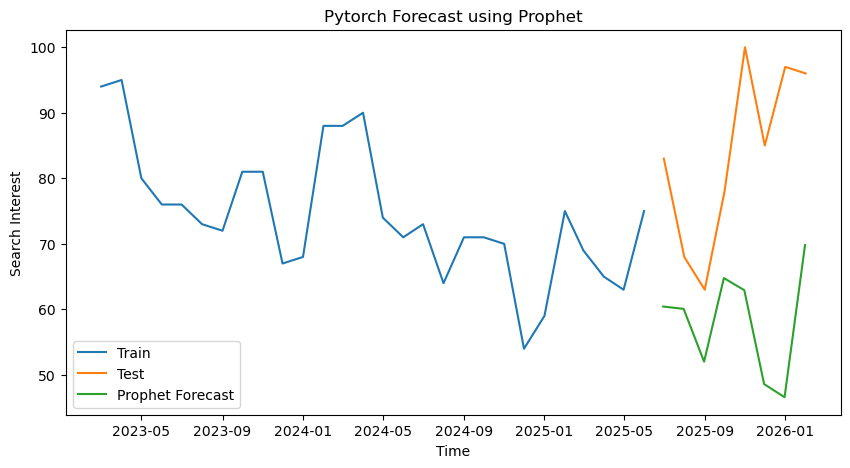

17:11:44 - cmdstanpy - INFO - Chain [1] start processing



Forecasting R


17:11:44 - cmdstanpy - INFO - Chain [1] done processing
17:11:44 - cmdstanpy - INFO - Chain [1] start processing


Prophet MAE: 3.8463920356385994
Prophet RMSE: 6.124362478284257


17:11:44 - cmdstanpy - INFO - Chain [1] done processing


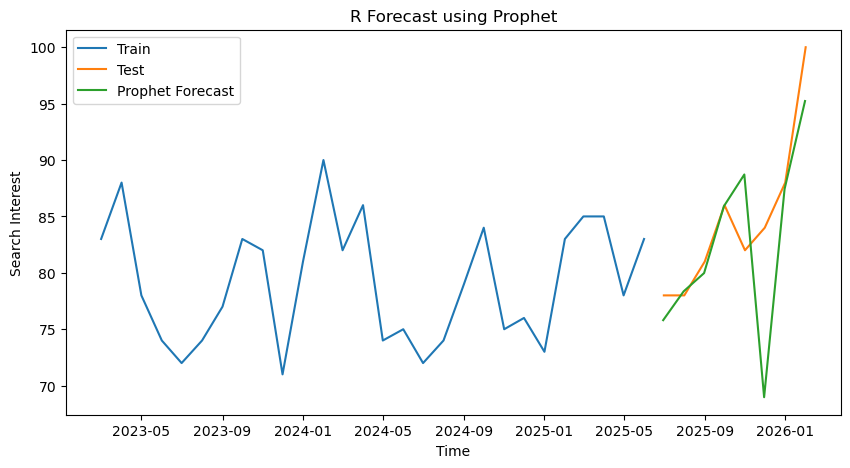

17:11:45 - cmdstanpy - INFO - Chain [1] start processing
17:11:45 - cmdstanpy - INFO - Chain [1] done processing



Forecasting Scikit-Learn


17:11:45 - cmdstanpy - INFO - Chain [1] start processing


Prophet MAE: 19.9423122547908
Prophet RMSE: 23.61246786278886


17:11:45 - cmdstanpy - INFO - Chain [1] done processing


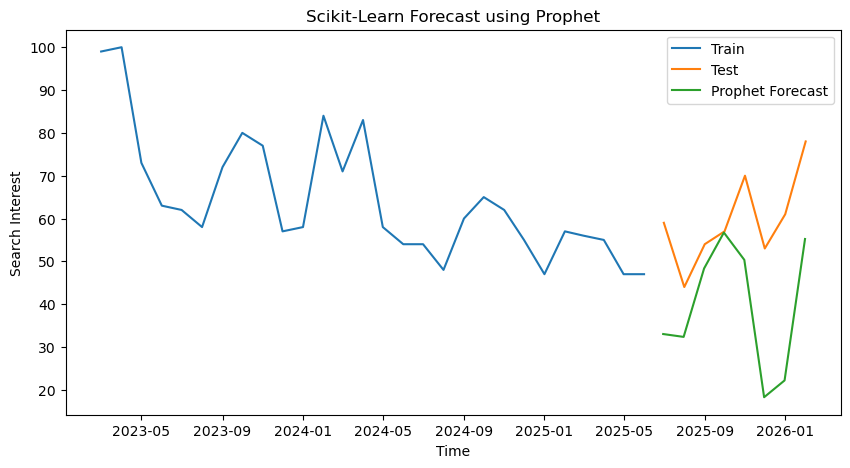

17:11:46 - cmdstanpy - INFO - Chain [1] start processing



Forecasting SQL


17:11:46 - cmdstanpy - INFO - Chain [1] done processing
17:11:46 - cmdstanpy - INFO - Chain [1] start processing


Prophet MAE: 8.124144494877218
Prophet RMSE: 8.642188422911921


17:11:46 - cmdstanpy - INFO - Chain [1] done processing


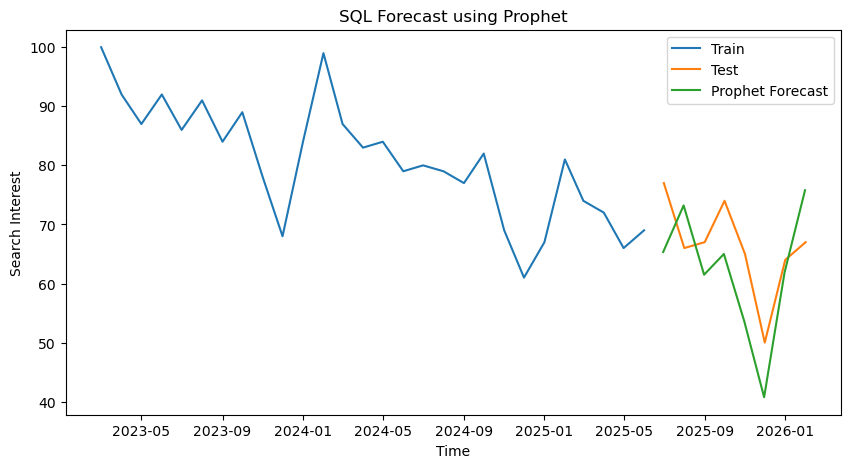

17:11:46 - cmdstanpy - INFO - Chain [1] start processing



Forecasting Statistics


17:11:47 - cmdstanpy - INFO - Chain [1] done processing
17:11:47 - cmdstanpy - INFO - Chain [1] start processing


Prophet MAE: 34.248955067399905
Prophet RMSE: 38.63971595683053


17:11:47 - cmdstanpy - INFO - Chain [1] done processing


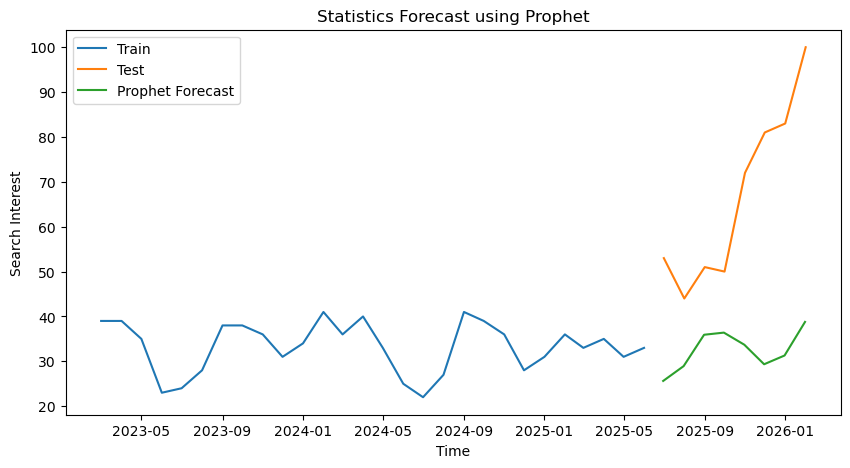

17:11:47 - cmdstanpy - INFO - Chain [1] start processing



Forecasting TensorFlow


17:11:47 - cmdstanpy - INFO - Chain [1] done processing
17:11:48 - cmdstanpy - INFO - Chain [1] start processing


Prophet MAE: 17.46544989358499
Prophet RMSE: 20.5356747351452


17:11:48 - cmdstanpy - INFO - Chain [1] done processing


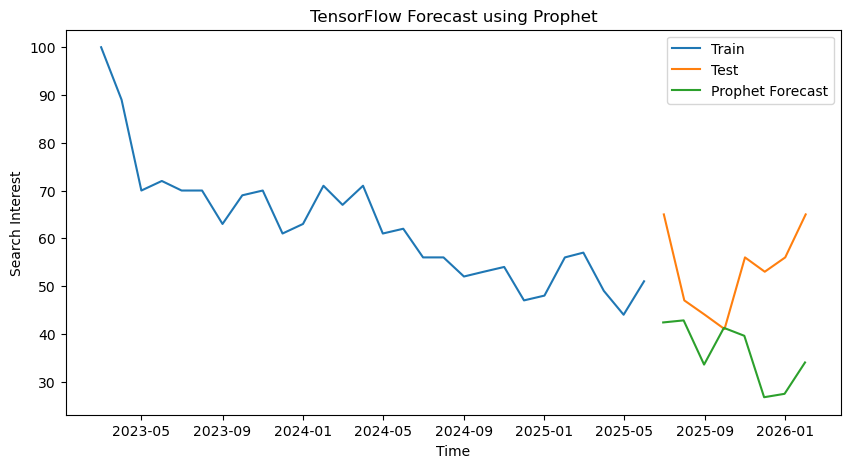

In [91]:
all_forecast_results = []
all_evaluation_results = []
future_forecast_results = []

for skill in skills_to_forecast:
    
    print("\n===================================")
    print(f"Forecasting {skill}")
    print("===================================")
    
    # 1. Extract the time series for one skill
    series = trend_df[skill].dropna()

    # 2. Split the time series into training and testing sets
    train, test = time_series_split(
        series,
        test_ratio=0.2
    )

    # 3. Convert the training and testing data into Prophet format
    # Prophet requires two columns: ds for date and y for target value
    prophet_train = train.reset_index()
    prophet_train.columns = ["ds", "y"]

    prophet_test = test.reset_index()
    prophet_test.columns = ["ds", "y"]

    # 4. Build the Prophet model
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    # 5. Train the model using the training data
    model.fit(prophet_train)

    # 6. Forecast the testing period
    future_test = model.make_future_dataframe(
        periods=len(prophet_test),
        freq="M"
    )

    forecast_test = model.predict(future_test)

    # 7. Extract predictions corresponding to the testing period
    prophet_pred = forecast_test["yhat"].iloc[-len(prophet_test):].values

    actual = prophet_test["y"].values

    # 8. Calculate model evaluation metrics
    prophet_mae = mean_absolute_error(
        actual,
        prophet_pred
    )

    prophet_rmse = np.sqrt(
        mean_squared_error(actual, prophet_pred)
    )

    print("Prophet MAE:", prophet_mae)
    print("Prophet RMSE:", prophet_rmse)

    # 9. Store evaluation results
    all_evaluation_results.append({
        "Skill": skill,
        "Prophet_MAE": prophet_mae,
        "Prophet_RMSE": prophet_rmse
    })

    # 10. Retrain the final Prophet model using the full historical series
    full_prophet_df = series.reset_index()
    full_prophet_df.columns = ["ds", "y"]

    final_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    final_model.fit(full_prophet_df)

    # 11. Forecast the next 12 months
    future_12 = final_model.make_future_dataframe(
        periods=12,
        freq="M"
    )

    forecast_12 = final_model.predict(future_12)

    # 12. Store the full forecast result
    temp_forecast = forecast_12[
        ["ds", "yhat", "yhat_lower", "yhat_upper"]
    ].copy()

    temp_forecast["Skill"] = skill

    all_forecast_results.append(temp_forecast)

    # 13. Store only the future 12-month forecast
    last_date = series.index.max()

    future_only = temp_forecast[
        temp_forecast["ds"] > last_date
    ].copy()

    future_only["Skill"] = skill

    future_forecast_results.append(future_only)

    # 14. Save the forecast result for each skill as a separate CSV file
    safe_skill_name = skill.replace(" ", "_").replace("/", "_")

    temp_forecast.to_csv(
        f"forecast_{safe_skill_name}.csv",
        index=False
    )

    # 15. Plot the training data, testing data, and Prophet forecast
    plt.figure(figsize=(10, 5))

    plt.plot(
        train.index,
        train,
        label="Train"
    )

    plt.plot(
        test.index,
        test,
        label="Test"
    )

    plt.plot(
        forecast_test["ds"].iloc[-len(test):],
        forecast_test["yhat"].iloc[-len(test):],
        label="Prophet Forecast"
    )

    plt.title(f"{skill} Forecast using Prophet")

    plt.xlabel("Time")

    plt.ylabel("Search Interest")

    plt.legend()

    plt.show()

In [93]:
all_forecasts_df = pd.concat(
    all_forecast_results,
    ignore_index=True
)

all_forecasts_df.head()

,ds,yhat,yhat_lower,yhat_upper,Skill
0,2023-03-01,93.019315,88.973003,96.862113,C++
1,2023-04-01,88.634074,84.645005,92.578303,C++
2,2023-05-01,73.095079,69.203429,77.120935,C++
3,2023-06-01,69.326107,64.996512,73.700708,C++
4,2023-07-01,71.453147,67.065014,75.394775,C++


In [95]:
all_forecasts_df.to_csv(
    "all_skills_prophet_forecasts.csv",
    index=False
)

In [97]:
evaluation_df = pd.DataFrame(
    all_evaluation_results
)

evaluation_df

,Skill,Prophet_MAE,Prophet_RMSE
0,C++,9.428242,10.949832
1,Cloud_Computing,22.663311,28.440845
2,Communication,10.520500,13.837821
3,Computer_Vision,30.006050,35.979413
4,Data_Visualization,16.049430,17.353220
5,Deep_Learning,37.151478,42.711854
6,Generative_AI,37.716024,39.375729
7,JAVA,13.768348,17.341151
8,Machine_Learning,28.034803,33.219011
9,MLOps,32.116279,34.454069


In [99]:
evaluation_df.to_csv(
    "time_series_model_evaluation.csv",
    index=False
)

In [101]:
future_forecasts_df = pd.concat(
    future_forecast_results,
    ignore_index=True
)

future_forecasts_df.head()

,ds,yhat,yhat_lower,yhat_upper,Skill
0,2026-02-28,64.280542,60.298934,68.342042,C++
1,2026-03-31,59.210131,55.003968,63.338186,C++
2,2026-04-30,41.079628,36.901428,45.032157,C++
3,2026-05-31,39.035728,34.844661,42.984492,C++
4,2026-06-30,40.239480,36.198864,44.522926,C++


In [103]:
future_forecasts_df.to_csv(
    "future_12_month_skill_forecasts.csv",
    index=False
)

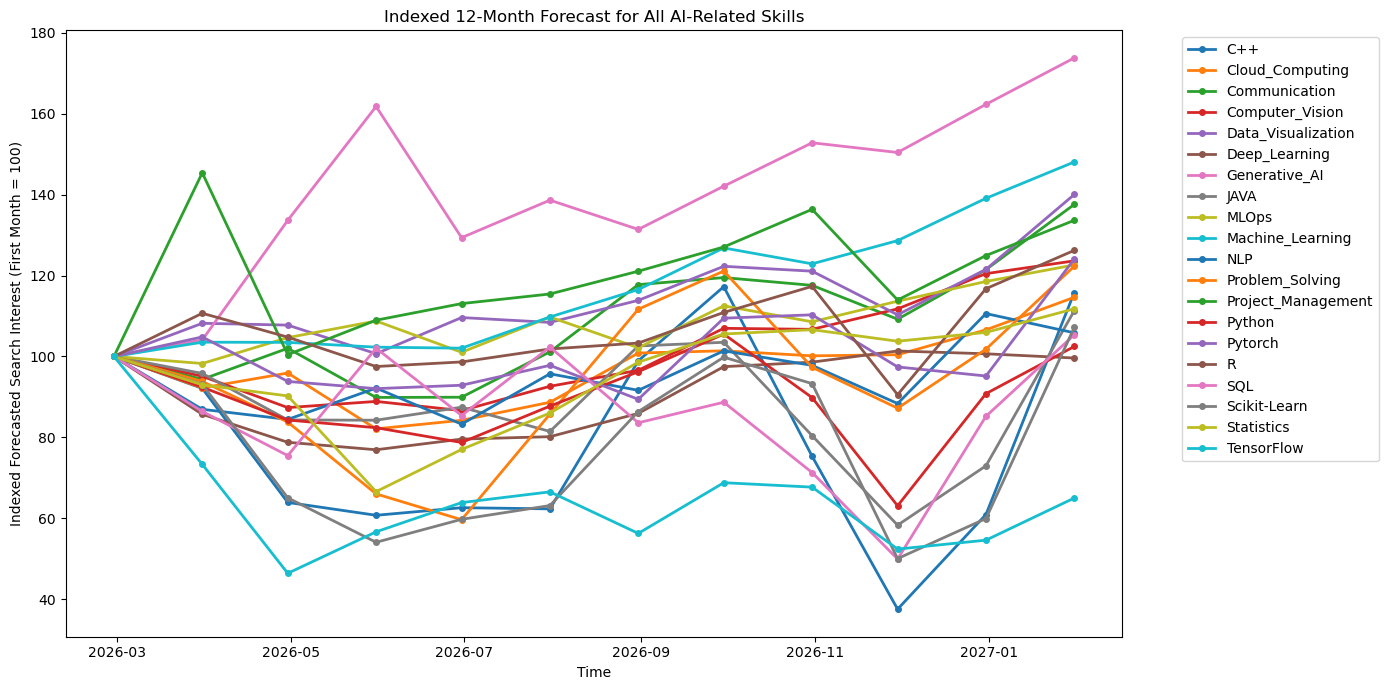

In [159]:
# Forecast Comparison of all skills
future_pivot = future_forecasts_df.pivot(
    index="ds",
    columns="Skill",
    values="yhat"
)

# Normalize each skill so the first forecast month = 100
future_indexed = future_pivot.div(future_pivot.iloc[0]) * 100

# Plot all skills as indexed forecast
plt.figure(figsize=(14, 7))

for skill in future_indexed.columns:
    plt.plot(
        future_indexed.index,
        future_indexed[skill],
        marker="o",
        markersize=4,  
        linewidth=2, 
        label=skill
    )

plt.title("Indexed 12-Month Forecast for All AI-Related Skills")
plt.xlabel("Time")
plt.ylabel("Indexed Forecasted Search Interest (First Month = 100)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [163]:
# Relative Growth Percentage Ranking
growth_pct_results = []

for skill in future_indexed.columns:
    
    start_value = future_indexed[skill].iloc[0]
    
    end_value = future_indexed[skill].iloc[-1]
    
    growth_pct = (
        (end_value - start_value)
        / start_value
    ) * 100
    
    growth_pct_results.append({
        "Skill": skill,
        "Relative_Growth_Pct": growth_pct
    })

growth_pct_df = pd.DataFrame(growth_pct_results)

growth_pct_df = growth_pct_df.sort_values(
    "Relative_Growth_Pct",
    ascending=False
)

growth_pct_df

,Skill,Relative_Growth_Pct
6,Generative_AI,73.842028
9,Machine_Learning,48.103675
4,Data_Visualization,40.058838
2,Communication,37.605291
12,Project_Management,33.674282
15,R,26.238756
14,Pytorch,24.103963
3,Computer_Vision,23.650851
8,MLOps,22.645802
11,Problem_Solving,22.328940


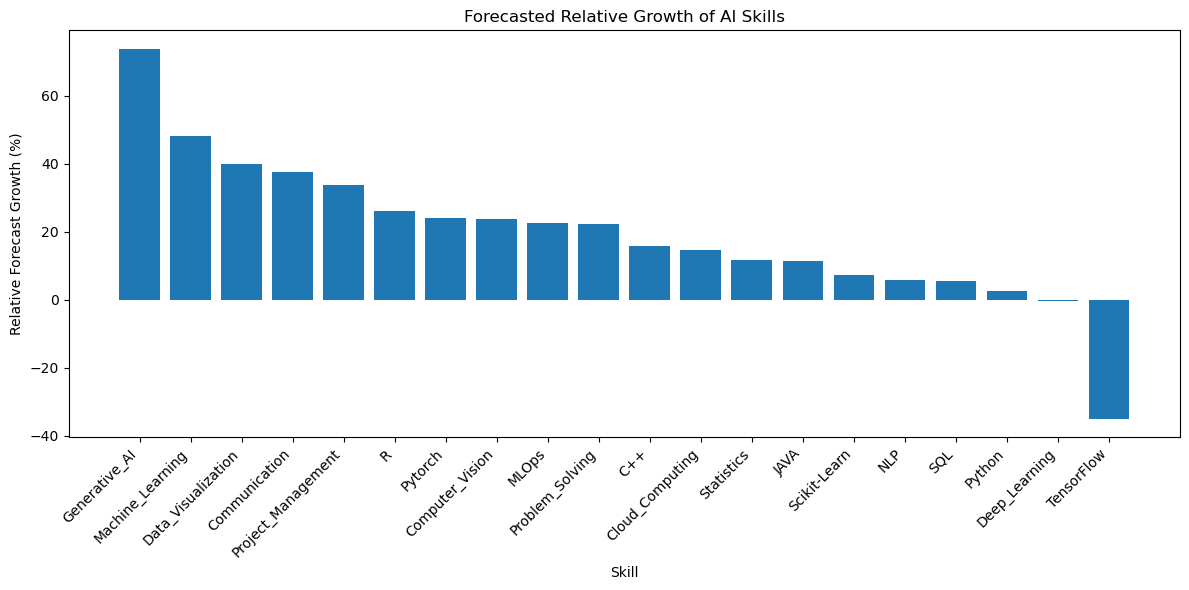

In [165]:
plt.figure(figsize=(12,6))

plt.bar(
    growth_pct_df["Skill"],
    growth_pct_df["Relative_Growth_Pct"]
)

plt.title("Forecasted Relative Growth of AI Skills")

plt.xlabel("Skill")

plt.ylabel("Relative Forecast Growth (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

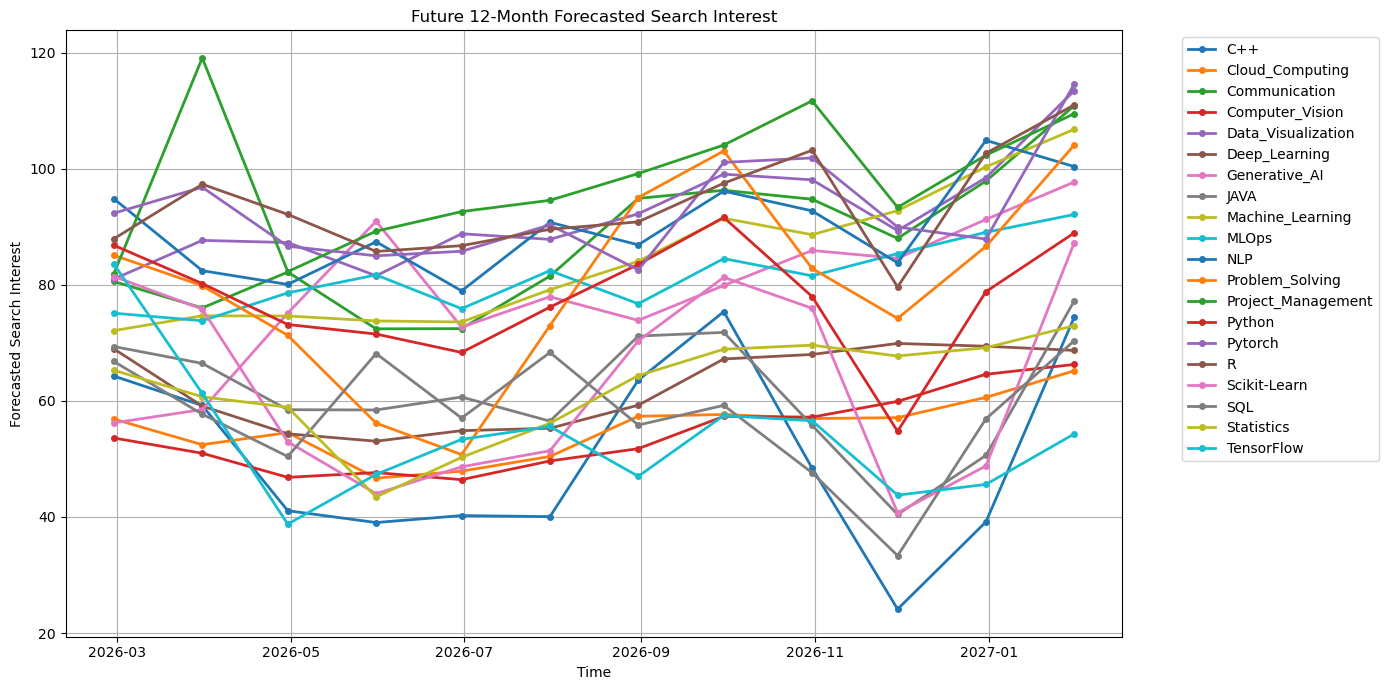

In [109]:
# Future 12-Month Forecasted
plt.figure(figsize=(14, 7))

for skill in skills_to_forecast:

    temp = future_forecasts_df[
        future_forecasts_df["Skill"] == skill
    ]

    plt.plot(
        temp["ds"],
        temp["yhat"],
        marker="o",      
        markersize=4,  
        linewidth=2, 
        label=skill
    )

plt.title("Future 12-Month Forecasted Search Interest")

plt.xlabel("Time")

plt.ylabel("Forecasted Search Interest")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [167]:
# Calculate Forecast Growth Ranking
growth_results = []

for skill in skills_to_forecast:
    
    historical_last = trend_df[skill].iloc[-1]

    future_skill = future_forecasts_df[
        future_forecasts_df["Skill"] == skill
    ]

    if len(future_skill) == 0:
        continue

    future_last = future_skill["yhat"].iloc[-1]

    growth = future_last - historical_last
    
    growth_pct = (
        growth / historical_last * 100
        if historical_last != 0
        else np.nan
    )

    growth_results.append({
        "Skill": skill,
        "Historical_Last": historical_last,
        "Forecast_12M": future_last,
        "Forecast_Growth": growth,
        "Forecast_Growth_Pct": growth_pct
    })

growth_df = pd.DataFrame(growth_results)

growth_df = growth_df.sort_values(
    "Forecast_Growth",
    ascending=False
)

growth_df

,Skill,Historical_Last,Forecast_12M,Forecast_Growth,Forecast_Growth_Pct
14,Pytorch,96,114.614337,18.614337,19.389935
4,Data_Visualization,100,113.461155,13.461155,13.461155
15,R,100,111.015449,11.015449,11.015449
2,Communication,100,110.882209,10.882209,10.882209
0,C++,64,74.441860,10.441860,16.315406
7,JAVA,67,77.222204,10.222204,15.257021
12,Project_Management,100,109.490993,9.490993,9.490993
16,Scikit-Learn,78,87.278107,9.278107,11.895010
8,Machine_Learning,100,106.810961,6.810961,6.810961
11,Problem_Solving,100,104.099642,4.099642,4.099642


In [169]:
growth_df.to_csv(
    "forecasted_skill_growth_ranking.csv",
    index=False
)

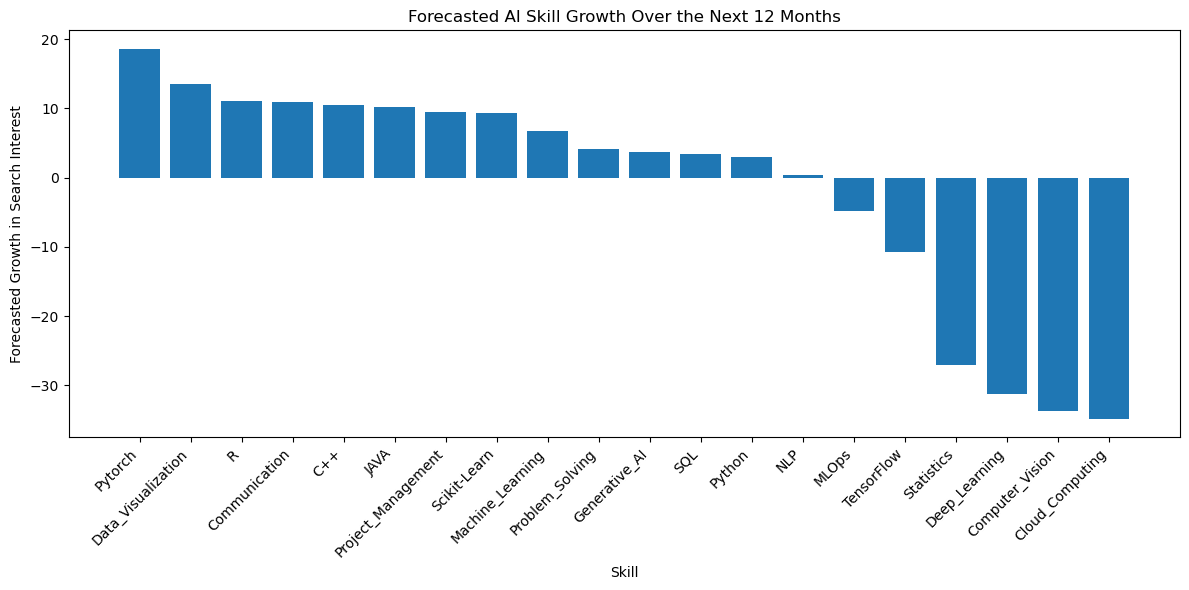

In [171]:
# Draw Forecast Growth Ranking
plt.figure(figsize=(12, 6))

plt.bar(
    growth_df["Skill"],
    growth_df["Forecast_Growth"]
)

plt.title("Forecasted AI Skill Growth Over the Next 12 Months")

plt.xlabel("Skill")

plt.ylabel("Forecasted Growth in Search Interest")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

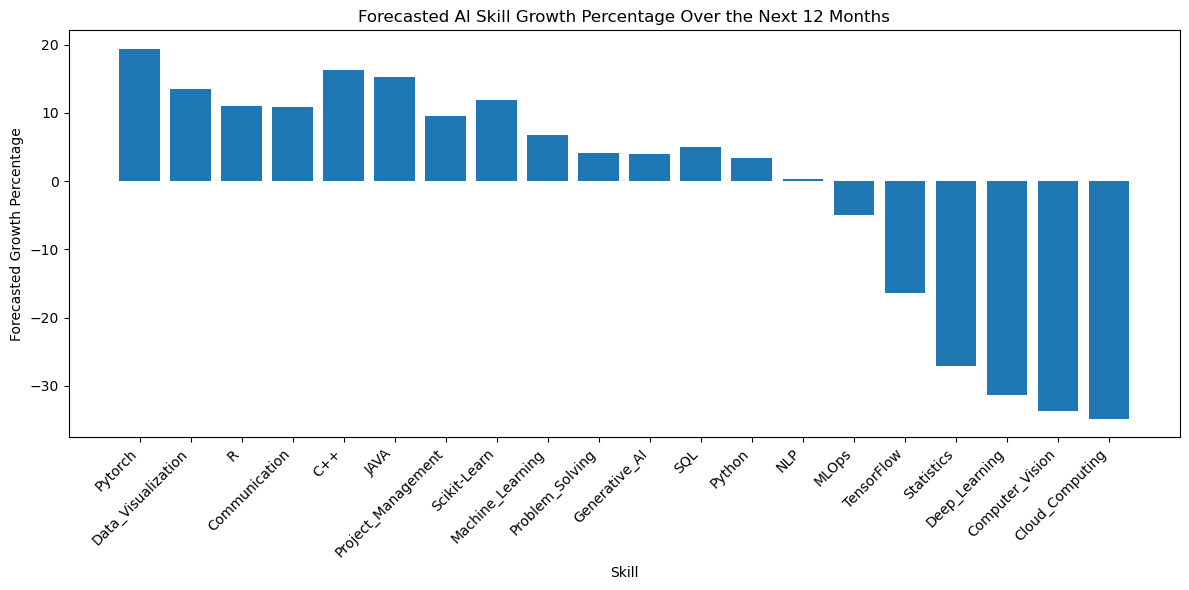

In [173]:
# Draw Forecast Growth Percentage Ranking
plt.figure(figsize=(12, 6))

plt.bar(
    growth_df["Skill"],
    growth_df["Forecast_Growth_Pct"]
)

plt.title("Forecasted AI Skill Growth Percentage Over the Next 12 Months")

plt.xlabel("Skill")

plt.ylabel("Forecasted Growth Percentage")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

In [123]:
# Top 5 Skills growing fast
top5_growth = growth_df.head(5)

top5_growth

,Skill,Historical_Last,Forecast_12M,Forecast_Growth,Forecast_Growth_Pct
14,Pytorch,96,114.614337,18.614337,0.193899
4,Data_Visualization,100,113.461155,13.461155,0.134612
15,R,100,111.015449,11.015449,0.110154
2,Communication,100,110.882209,10.882209,0.108822
0,C++,64,74.441860,10.441860,0.163154


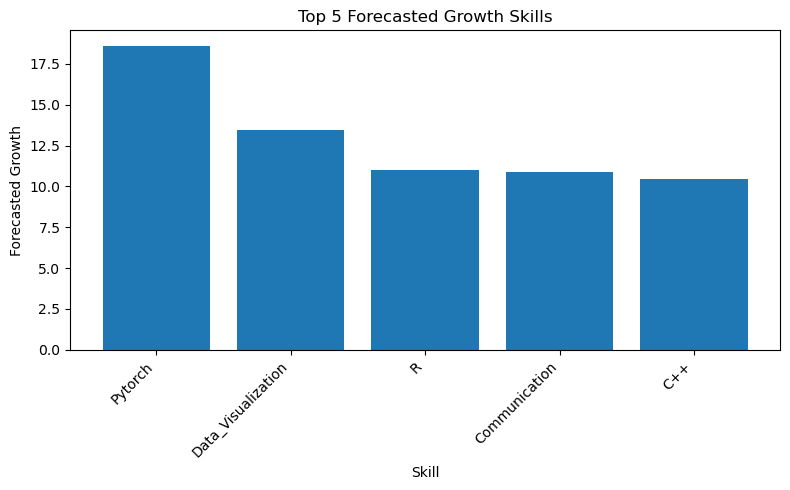

In [125]:
plt.figure(figsize=(8, 5))

plt.bar(
    top5_growth["Skill"],
    top5_growth["Forecast_Growth"]
)

plt.title("Top 5 Forecasted Growth Skills")

plt.xlabel("Skill")

plt.ylabel("Forecasted Growth")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

In [127]:
# 5 skills growing slow
bottom5_growth = growth_df.tail(5)

bottom5_growth

,Skill,Historical_Last,Forecast_12M,Forecast_Growth,Forecast_Growth_Pct
19,TensorFlow,65,54.317384,-10.682616,-0.164348
18,Statistics,100,72.973861,-27.026139,-0.270261
5,Deep_Learning,100,68.702310,-31.297690,-0.312977
3,Computer_Vision,100,66.282378,-33.717622,-0.337176
1,Cloud_Computing,100,65.187993,-34.812007,-0.348120


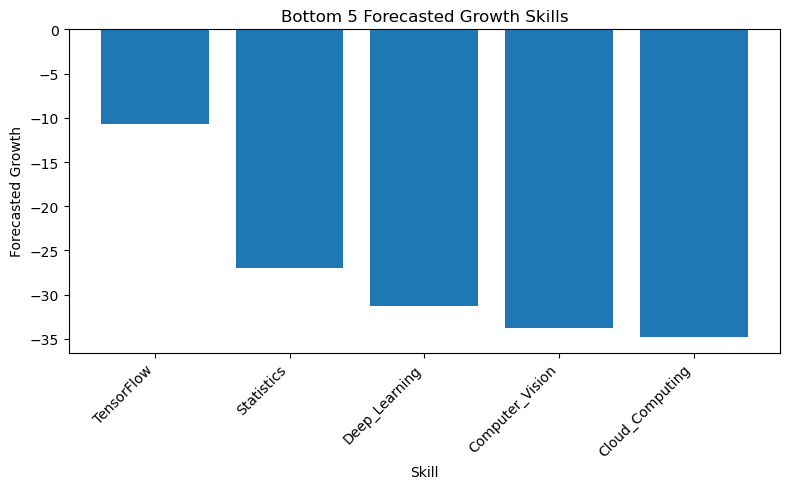

In [129]:
plt.figure(figsize=(8, 5))

plt.bar(
    bottom5_growth["Skill"],
    bottom5_growth["Forecast_Growth"]
)

plt.title("Bottom 5 Forecasted Growth Skills")

plt.xlabel("Skill")

plt.ylabel("Forecasted Growth")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

In [131]:
trend_df.to_csv(
    "cleaned_google_trends_time_series.csv"
)

In [133]:
# Using Job Posting to make Monthly Skill Demand Forecast
job_df = pd.read_csv("adzuna_ai_all_available.csv")

job_df.head()

,Post_Date,Title,Label,Company,Location,Description,URL,Salary_Max,Salary_Min
0,2026-03-01T11:37:42Z,"Senior Product Manager, AI",IT Jobs,Humana,"The Colony, Denton County",Become a part of our caring community and help...,https://www.adzuna.com/land/ad/5650251083?se=Z...,207575.80,207575.80
1,2026-03-01T12:48:31Z,"Senior Product Manager, AI",IT Jobs,Humana,US,Become a part of our caring community and help...,https://www.adzuna.com/land/ad/5650278452?se=Z...,203586.53,203586.53
2,2026-03-01T11:56:05Z,"Lead, AI Product Management",IT Jobs,Humana,"The Colony, Denton County",Become a part of our caring community and help...,https://www.adzuna.com/land/ad/5650258239?se=Z...,157985.38,157985.38
3,2026-03-03T01:14:10Z,"Lead, AI Product Management",IT Jobs,Humana,US,Become a part of our caring community and help...,https://www.adzuna.com/land/ad/5652057718?se=Z...,158968.52,158968.52
4,2026-03-03T01:27:18Z,Senior AI Product Management,IT Jobs,Humana,US,Become a part of our caring community and help...,https://www.adzuna.com/land/ad/5652059423?se=Z...,169193.67,169193.67


In [135]:
job_df.columns.tolist()

['Post_Date',
 'Title',
 'Label',
 'Company',
 'Location',
 'Description',
 'URL',
 'Salary_Max',
 'Salary_Min']

In [137]:
job_df["Post_Date"] = pd.to_datetime(
    job_df["Post_Date"],
    errors="coerce"
)

job_df = job_df.dropna(subset=["Post_Date"])

job_df["YearMonth"] = job_df["Post_Date"].dt.to_period("M").dt.to_timestamp()

job_df.head()

,Post_Date,Title,Label,Company,Location,Description,URL,Salary_Max,Salary_Min,YearMonth
0,2026-03-01 11:37:42+00:00,"Senior Product Manager, AI",IT Jobs,Humana,"The Colony, Denton County",Become a part of our caring community and help...,https://www.adzuna.com/land/ad/5650251083?se=Z...,207575.80,207575.80,2026-03-01
1,2026-03-01 12:48:31+00:00,"Senior Product Manager, AI",IT Jobs,Humana,US,Become a part of our caring community and help...,https://www.adzuna.com/land/ad/5650278452?se=Z...,203586.53,203586.53,2026-03-01
2,2026-03-01 11:56:05+00:00,"Lead, AI Product Management",IT Jobs,Humana,"The Colony, Denton County",Become a part of our caring community and help...,https://www.adzuna.com/land/ad/5650258239?se=Z...,157985.38,157985.38,2026-03-01
3,2026-03-03 01:14:10+00:00,"Lead, AI Product Management",IT Jobs,Humana,US,Become a part of our caring community and help...,https://www.adzuna.com/land/ad/5652057718?se=Z...,158968.52,158968.52,2026-03-01
4,2026-03-03 01:27:18+00:00,Senior AI Product Management,IT Jobs,Humana,US,Become a part of our caring community and help...,https://www.adzuna.com/land/ad/5652059423?se=Z...,169193.67,169193.67,2026-03-01


In [139]:
job_df["text"] = (
    job_df["Title"].fillna("") + " " +
    job_df["Description"].fillna("")
).str.lower()

In [141]:
job_skill_patterns = {
    "Python": r"\bpython\b",
    "SQL": r"\bsql\b",
    "Machine_Learning": r"machine learning|\bml\b",
    "Deep_Learning": r"deep learning|neural network|neural networks",
    "NLP": r"\bnlp\b|natural language processing",
    "Computer_Vision": r"computer vision|image recognition|object detection",
    "Generative_AI": r"generative ai|genai|large language model|llm|chatgpt",
    "Cloud_Computing": r"cloud|aws|azure|gcp|google cloud",
    "Big_Data": r"big data|spark|hadoop|databricks",
    "MLOps": r"mlops|model deployment|model monitoring|docker|kubernetes"
}

In [143]:
for skill, pattern in job_skill_patterns.items():
    job_df[skill] = job_df["text"].str.contains(
        pattern,
        regex=True,
        na=False
    ).astype(int)

job_skill_cols = list(job_skill_patterns.keys())

job_df[job_skill_cols].head()

,Python,SQL,Machine_Learning,Deep_Learning,NLP,Computer_Vision,Generative_AI,Cloud_Computing,Big_Data,MLOps
0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0


In [145]:
monthly_job_skill_demand = job_df.groupby("YearMonth")[job_skill_cols].sum()

monthly_job_skill_demand.head()

,Python,SQL,Machine_Learning,Deep_Learning,NLP,Computer_Vision,Generative_AI,Cloud_Computing,Big_Data,MLOps
YearMonth,,,,,,,,,,
2025-05-01,0,0,0,0,0,0,1,1,0,0
2025-06-01,0,0,5,0,0,1,2,0,0,0
2025-07-01,0,0,0,0,0,0,0,1,0,0
2025-08-01,0,0,44,0,0,0,3,40,0,1
2025-09-01,1,0,2,0,1,0,4,0,0,1


In [147]:
monthly_job_skill_demand.to_csv(
    "monthly_job_skill_demand.csv"
)

In [219]:
monthly_job_skill_demand_clean = monthly_job_skill_demand.copy()

# Remove March 2026 because it only contains partial-month data
monthly_job_skill_demand_clean = monthly_job_skill_demand_clean[
    monthly_job_skill_demand_clean.index < "2026-03-01"
]

monthly_job_skill_demand_clean.tail()

,Python,SQL,Machine_Learning,Deep_Learning,NLP,Computer_Vision,Generative_AI,Cloud_Computing,Big_Data,MLOps
YearMonth,,,,,,,,,,
2025-10-01,0,0,79,4,4,4,77,62,0,0
2025-11-01,0,0,17,1,25,0,34,34,0,0
2025-12-01,44,0,72,2,8,5,262,166,0,0
2026-01-01,43,41,142,3,56,2,179,218,22,0
2026-02-01,14,0,362,7,5,3,217,291,17,48


15:02:42 - cmdstanpy - INFO - Chain [1] start processing
15:02:42 - cmdstanpy - INFO - Chain [1] done processing



Forecasting employer demand for Python


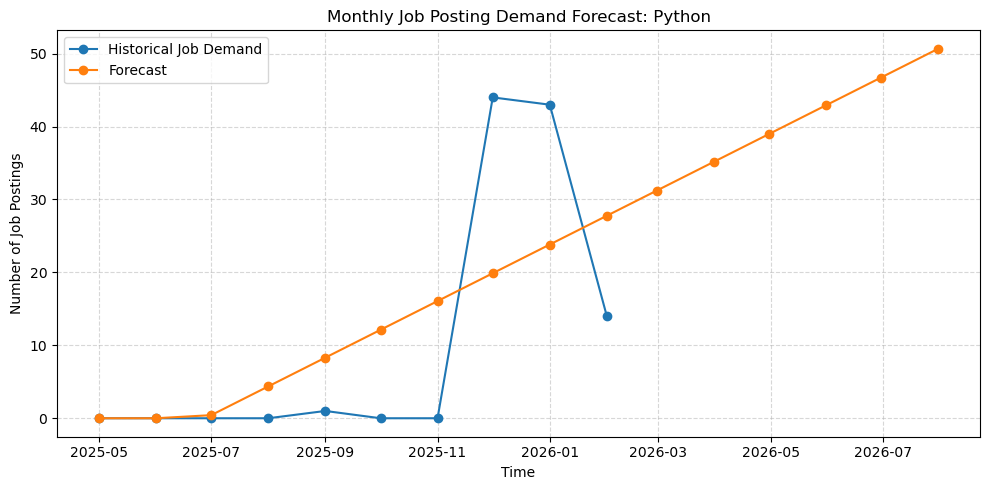

15:02:42 - cmdstanpy - INFO - Chain [1] start processing
15:02:42 - cmdstanpy - INFO - Chain [1] done processing



Forecasting employer demand for SQL


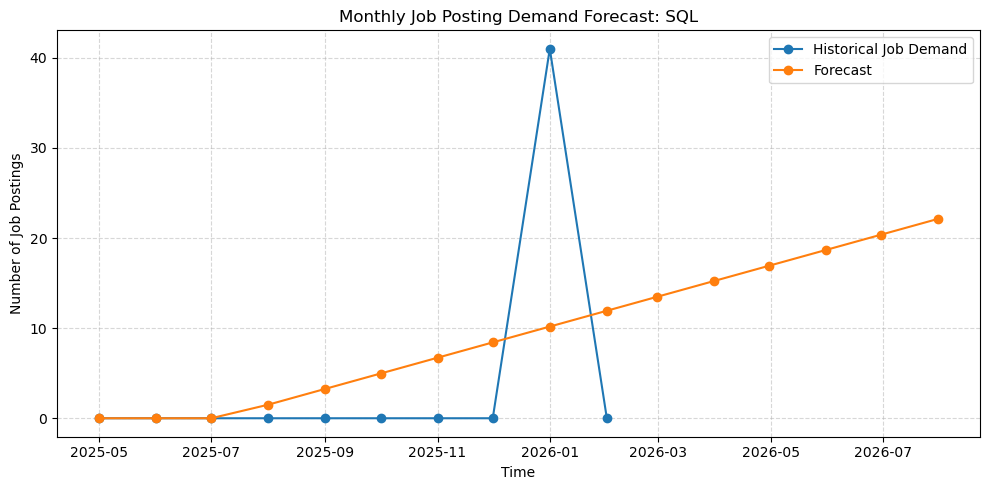

15:02:43 - cmdstanpy - INFO - Chain [1] start processing
15:02:43 - cmdstanpy - INFO - Chain [1] done processing



Forecasting employer demand for Machine_Learning


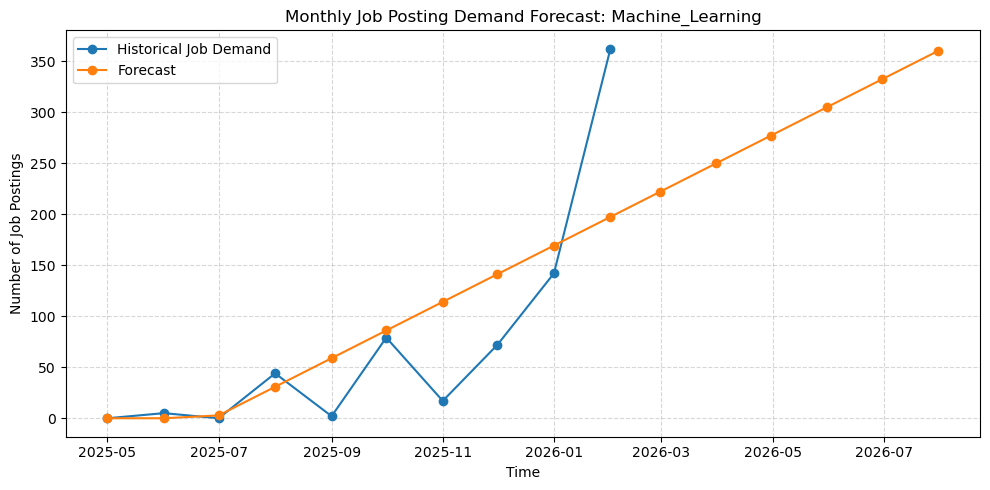

15:02:43 - cmdstanpy - INFO - Chain [1] start processing
15:02:43 - cmdstanpy - INFO - Chain [1] done processing



Forecasting employer demand for Deep_Learning


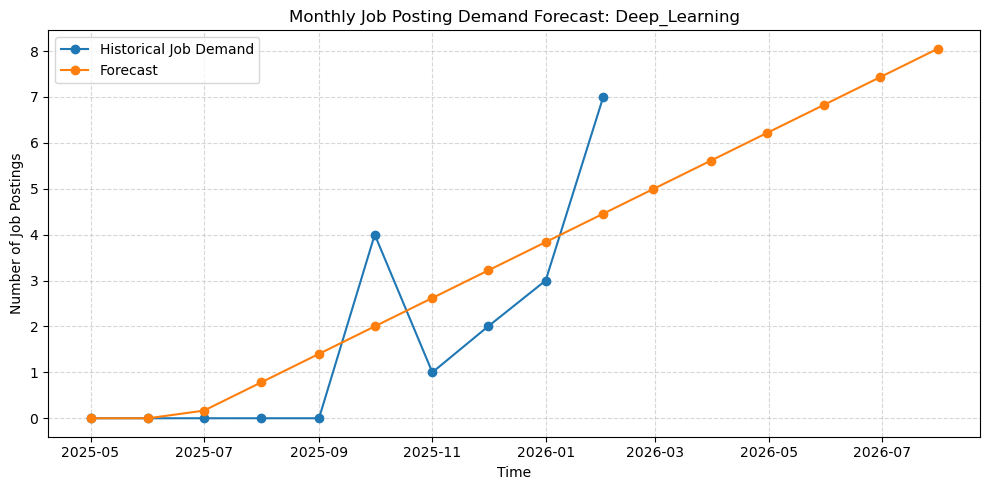

15:02:43 - cmdstanpy - INFO - Chain [1] start processing
15:02:43 - cmdstanpy - INFO - Chain [1] done processing



Forecasting employer demand for NLP


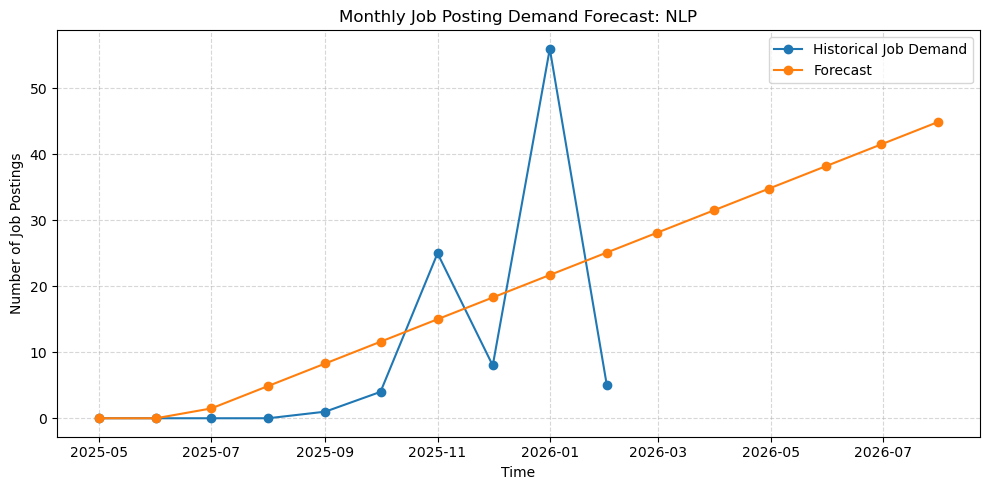

15:02:44 - cmdstanpy - INFO - Chain [1] start processing
15:02:44 - cmdstanpy - INFO - Chain [1] done processing



Forecasting employer demand for Computer_Vision


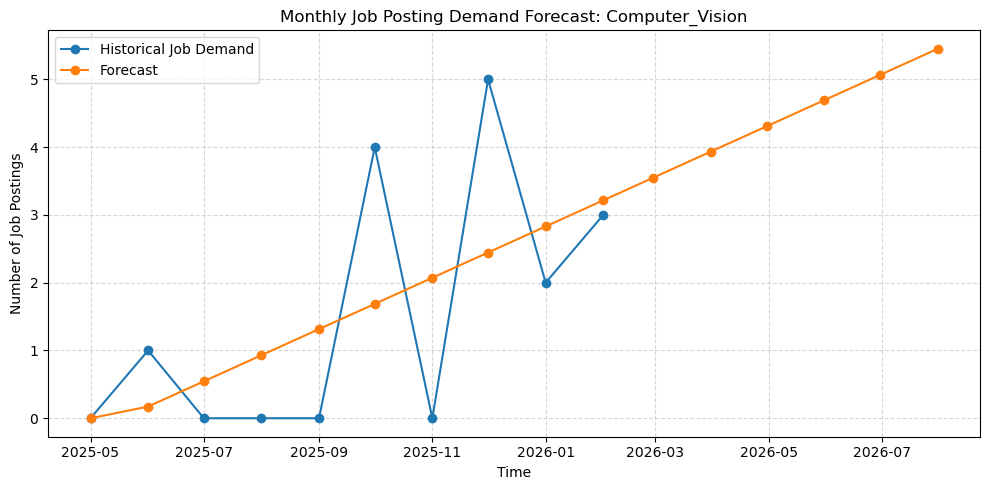

15:02:44 - cmdstanpy - INFO - Chain [1] start processing
15:02:44 - cmdstanpy - INFO - Chain [1] done processing



Forecasting employer demand for Generative_AI


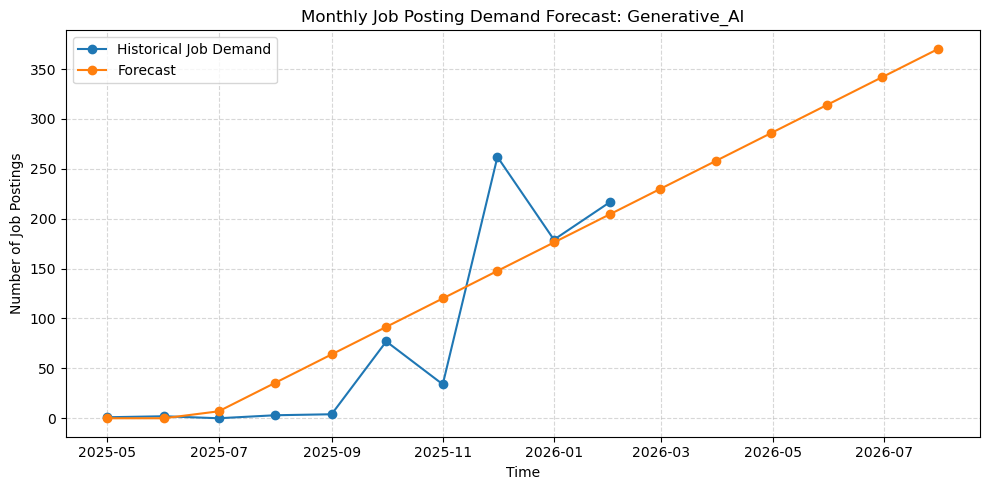

15:02:44 - cmdstanpy - INFO - Chain [1] start processing
15:02:44 - cmdstanpy - INFO - Chain [1] done processing



Forecasting employer demand for Cloud_Computing


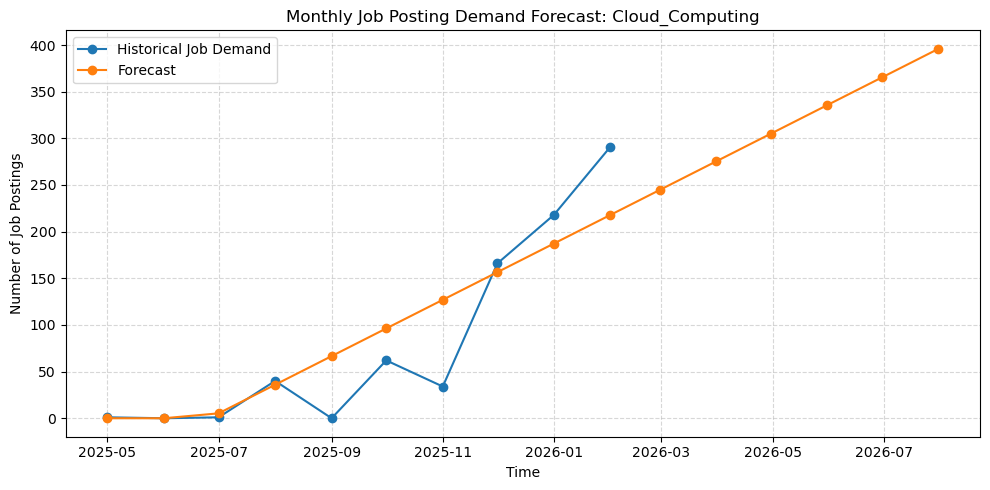

15:02:45 - cmdstanpy - INFO - Chain [1] start processing
15:02:45 - cmdstanpy - INFO - Chain [1] done processing



Forecasting employer demand for Big_Data


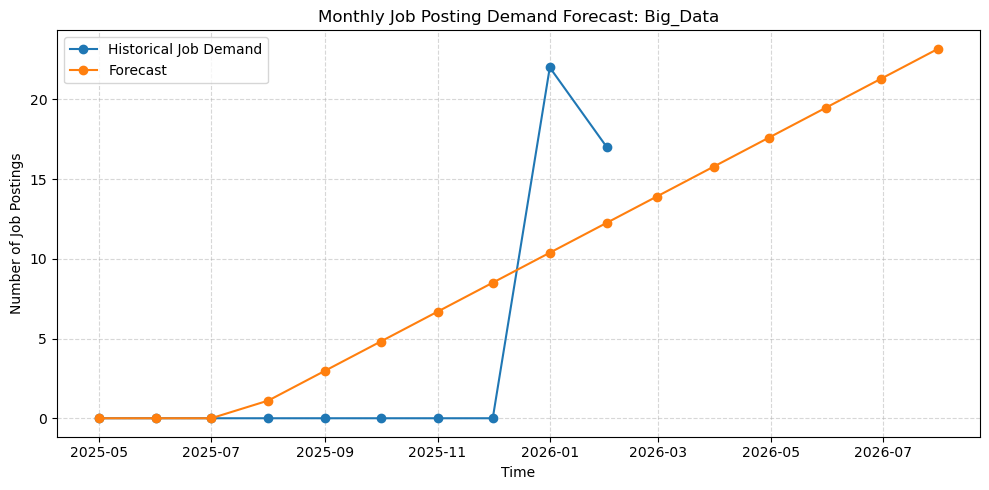

15:02:45 - cmdstanpy - INFO - Chain [1] start processing
15:02:45 - cmdstanpy - INFO - Chain [1] done processing



Forecasting employer demand for MLOps


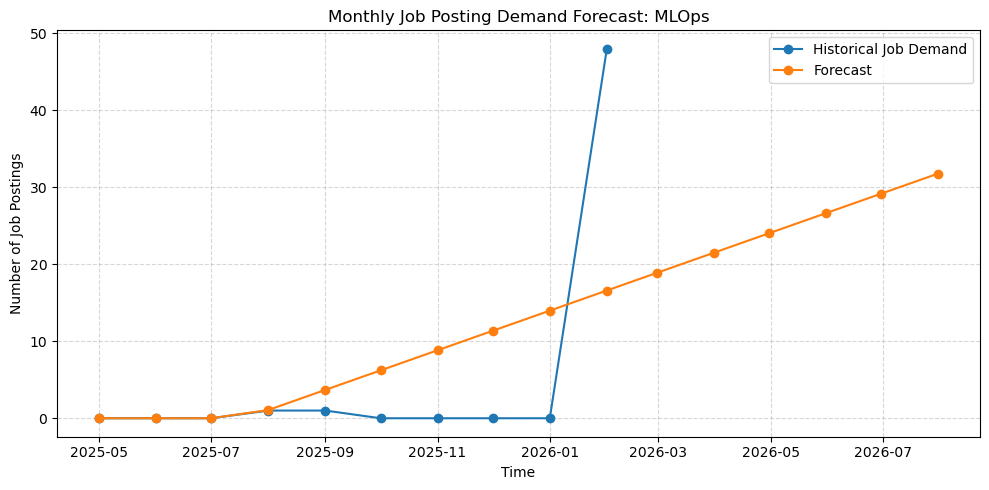

In [259]:
# --------------------------------------------
# 2. Run Prophet forecast for each job skill
# --------------------------------------------

job_forecast_results = []

for skill in job_skill_cols:
    
    print("\n===================================")
    print(f"Forecasting employer demand for {skill}")
    print("===================================")
    
    # Extract monthly employer demand series for the current skill
    series = monthly_job_skill_demand_clean[skill]
    
    # Convert data into Prophet format
    prophet_df = series.reset_index()
    prophet_df.columns = ["ds", "y"]
    
    # Build Prophet model
    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
    )
    
    # Train model
    model.fit(prophet_df)
    
    # Forecast the next 6 months
    future = model.make_future_dataframe(
        periods=6,
        freq="M"
    )
    
    forecast = model.predict(future)
    
    # Job posting counts cannot be negative
    forecast["yhat"] = forecast["yhat"].clip(lower=0)
    forecast["yhat_lower"] = forecast["yhat_lower"].clip(lower=0)
    forecast["yhat_upper"] = forecast["yhat_upper"].clip(lower=0)
    
    # Store forecast result
    temp = forecast[
        ["ds", "yhat", "yhat_lower", "yhat_upper"]
    ].copy()
    
    temp["Skill"] = skill
    
    job_forecast_results.append(temp)

    # Plot historical demand and forecast for each skill
    plt.figure(figsize=(10, 5))

    plt.plot(
        series.index,
        series,
        marker="o",
        label="Historical Job Demand"
    )

    plt.plot(
        forecast["ds"],
        forecast["yhat"],
        marker="o",
        label="Forecast"
    )

    plt.title(f"Monthly Job Posting Demand Forecast: {skill}")
    plt.xlabel("Time")
    plt.ylabel("Number of Job Postings")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

In [237]:
# --------------------------------------------
# 3. Combine all job posting forecast results
# --------------------------------------------

job_forecasts_df = pd.concat(
    job_forecast_results,
    ignore_index=True
)

job_forecasts_df.head()

,ds,yhat,yhat_lower,yhat_upper,Skill
0,2025-05-01,0.000000,0.0,9.777689,Python
1,2025-06-01,0.000000,0.0,11.727495,Python
2,2025-07-01,0.424547,0.0,15.474584,Python
3,2025-08-01,4.367442,0.0,19.753667,Python
4,2025-09-01,8.310337,0.0,24.164359,Python


In [239]:
# --------------------------------------------
# 4. Extract future-only forecasts
# --------------------------------------------

last_job_date = monthly_job_skill_demand_clean.index.max()

job_future_only = job_forecasts_df[
    job_forecasts_df["ds"] > last_job_date
].copy()

job_future_only.head()

,ds,yhat,yhat_lower,yhat_upper,Skill
10,2026-02-28,31.204565,16.091710,48.417914,Python
11,2026-03-31,35.147460,18.639747,51.238333,Python
12,2026-04-30,38.963164,21.673749,53.827016,Python
13,2026-05-31,42.906059,25.862948,57.306219,Python
14,2026-06-30,46.721764,31.448479,62.406781,Python


In [241]:
# Save future-only forecast results
job_future_only.to_csv(
    "future_job_posting_skill_demand_forecasts.csv",
    index=False
)

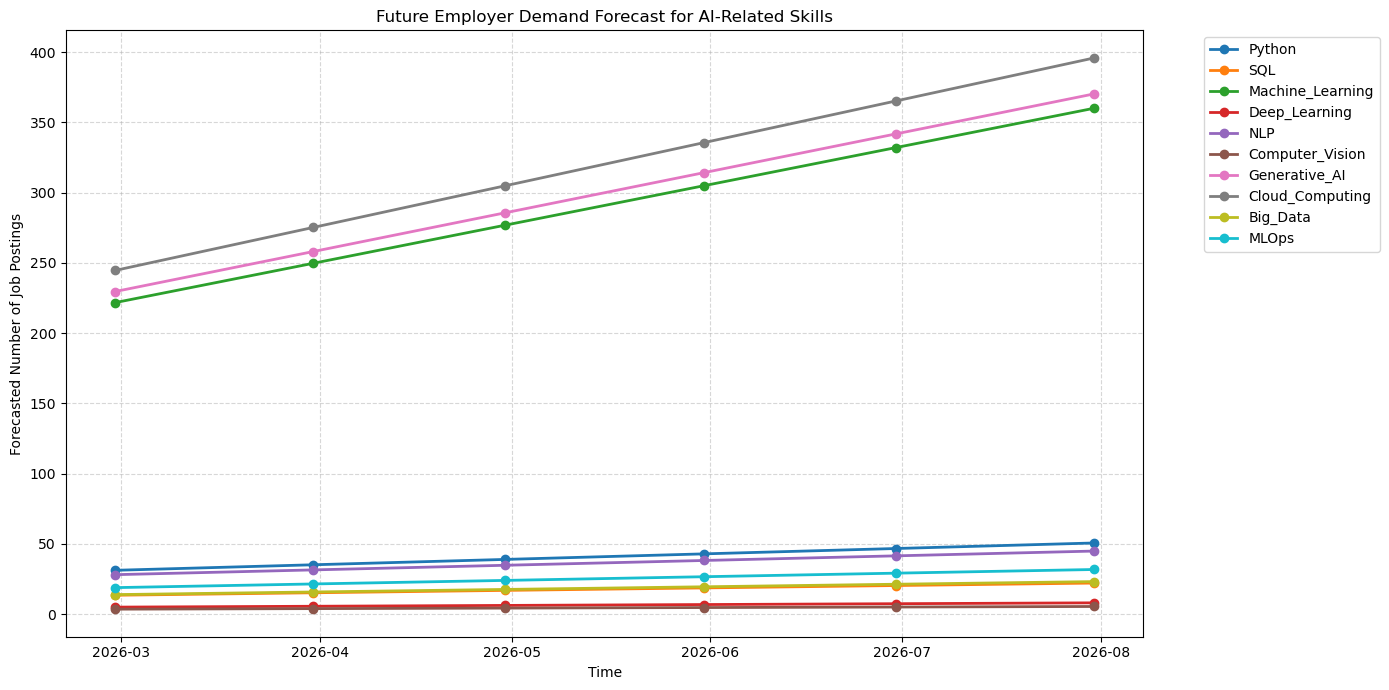

In [263]:
# --------------------------------------------
# 5. Plot future employer demand forecast
# --------------------------------------------

plt.figure(figsize=(14, 7))

for skill in job_skill_cols:
    
    temp = job_future_only[
        job_future_only["Skill"] == skill
    ]
    
    plt.plot(
        temp["ds"],
        temp["yhat"],
        marker="o",
        linewidth=2,
        label=skill
    )

plt.title("Future Employer Demand Forecast for AI-Related Skills")
plt.xlabel("Time")
plt.ylabel("Forecasted Number of Job Postings")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

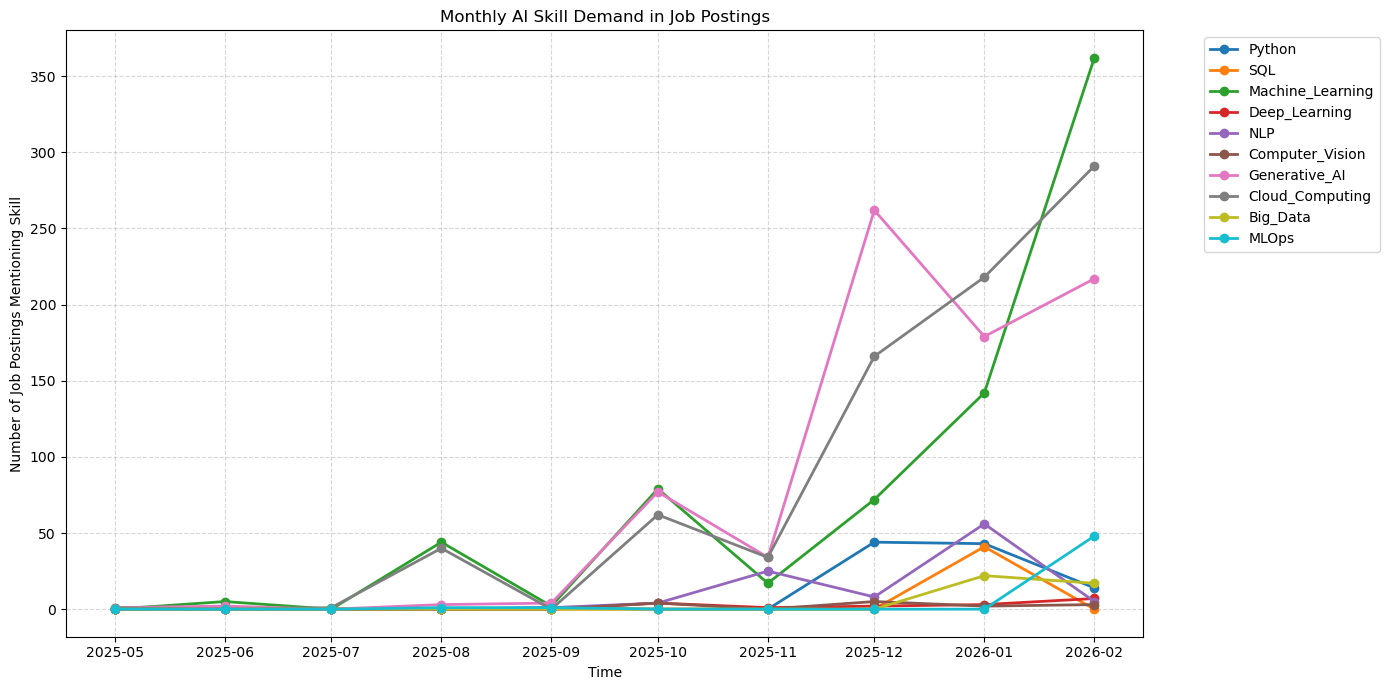

In [245]:
# --------------------------------------------
# 7. Recommended PPT chart: Historical monthly employer demand
# --------------------------------------------

plt.figure(figsize=(14, 7))

for col in monthly_job_skill_demand_clean.columns:
    
    plt.plot(
        monthly_job_skill_demand_clean.index,
        monthly_job_skill_demand_clean[col],
        marker="o",
        linewidth=2,
        label=col
    )

plt.title("Monthly AI Skill Demand in Job Postings")
plt.xlabel("Time")
plt.ylabel("Number of Job Postings Mentioning Skill")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()